<a href="https://colab.research.google.com/github/enikulchev/EN/blob/main/Phys%20Lett%20A.ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
# ======================================================================
# Complex Lorenz system: full identification of a 5D chaotic model
# Canonical SO(2) basis (Weyl's theorem)
# ======================================================================
import numpy as np
from scipy.integrate import solve_ivp
from sklearn.linear_model import RidgeCV
from sklearn.preprocessing import StandardScaler

# ======================================================================
# 1. Reference trajectory
# ======================================================================
sigma = 10.0
r1 = 28.0
r2 = 0.0
b = 8.0 / 3.0
e = 0.1

dt = 0.01
t = np.arange(0, 100, dt)
N = len(t)

def complex_lorenz(t, state):
    x1, x2, y1, y2, z = state
    return np.array([
        -sigma * x1 + sigma * y1,
        -sigma * x2 + sigma * y2,
        (r1 - z) * x1 - r2 * x2 - y1 - e * y2,
         r2 * x1 + (r1 - z) * x2 + e * y1 - y2,
        -b * z + x1 * y1 + x2 * y2,
    ])

x0 = [1.0, 0.0, 1.0, 0.0, 20.0]

sol = solve_ivp(complex_lorenz, (t[0], t[-1]), x0,
                t_eval=t, method='LSODA', rtol=1e-10, atol=1e-12)
X = sol.y.T

print("Reference amplitudes:")
for j, name in enumerate(['x1', 'x2', 'y1', 'y2', 'z']):
    print(f"  {name}: min = {X[:,j].min():8.3f}, max = {X[:,j].max():8.3f}")

# ======================================================================
# 2. Derivatives (central differences)
# ======================================================================
def deriv(y, dt):
    d = np.zeros_like(y)
    d[1:-1] = (y[2:] - y[:-2]) / (2 * dt)
    d[0] = (y[1] - y[0]) / dt
    d[-1] = (y[-1] - y[-2]) / dt
    return d

dX = np.column_stack([deriv(X[:, j], dt) for j in range(5)])

# ======================================================================
# 3. Canonical SO(2) basis (Weyl's theorem)
#    odd (equivariant):  x1, x2, y1, y2, z*x1, z*x2, z*y1, z*y2
#    even (invariant):   1, z, Re(x y*) = x1*y1 + x2*y2
# ======================================================================
def basis_eq(x1, x2, y1, y2, z):
    return np.array([x1, x2, y1, y2, z*x1, z*x2, z*y1, z*y2])

def basis_inv(x1, x2, y1, y2, z):
    return np.array([1.0, z, x1*y1 + x2*y2])

Phi_eq  = np.array([basis_eq( *X[i]) for i in range(N)])
Phi_inv = np.array([basis_inv(*X[i]) for i in range(N)])

# ======================================================================
# 4. Identification (RidgeCV)
# ======================================================================
coefs = {}
print()
for j, name in enumerate(['x1', 'x2', 'y1', 'y2', 'z']):
    Phi = Phi_eq if j < 4 else Phi_inv
    scaler = StandardScaler()
    Phi_s = scaler.fit_transform(Phi)
    ridge = RidgeCV(alphas=np.logspace(-6, 2, 20))
    ridge.fit(Phi_s, dX[:, j])
    c_raw = ridge.coef_ / scaler.scale_
    c0 = ridge.intercept_ - np.sum(ridge.coef_ * scaler.mean_ / scaler.scale_)
    pred = ridge.predict(Phi_s)
    mse = np.mean((dX[:, j] - pred)**2)
    coefs[name] = (c_raw, c0)
    print(f"d{name}/dt: MSE = {mse:.3e}")

# ======================================================================
# 5. Print identified equations
# ======================================================================
labels = {
    'x1': ['x1', 'x2', 'y1', 'y2', 'z*x1', 'z*x2', 'z*y1', 'z*y2'],
    'x2': ['x1', 'x2', 'y1', 'y2', 'z*x1', 'z*x2', 'z*y1', 'z*y2'],
    'y1': ['x1', 'x2', 'y1', 'y2', 'z*x1', 'z*x2', 'z*y1', 'z*y2'],
    'y2': ['x1', 'x2', 'y1', 'y2', 'z*x1', 'z*x2', 'z*y1', 'z*y2'],
    'z':  ['1', 'z', 'Re(xy*)'],
}
theory = {
    'x1': {'x1': -sigma, 'y1': sigma},
    'x2': {'x2': -sigma, 'y2': sigma},
    'y1': {'x1': r1, 'z*x1': -1.0, 'y1': -1.0, 'y2': -e},
    'y2': {'x2': r1, 'z*x2': -1.0, 'y2': -1.0, 'y1': e},
    'z':  {'1': 0.0, 'z': -b, 'Re(xy*)': 1.0},
}

print("\n" + "=" * 70)
print("IDENTIFIED EQUATIONS")
print("=" * 70)

for name in ['x1', 'x2', 'y1', 'y2', 'z']:
    c, c0 = coefs[name]
    print(f"\nd{name}/dt = {c0:+.6f}")
    for lab, val in zip(labels[name], c):
        marker = ""
        if lab in theory[name]:
            th = theory[name][lab]
            if abs(th) > 1e-12:
                err = abs(val - th) / abs(th) * 100
                marker = f"  (theory {th:+.4f}, error {err:.2f}%)"
        print(f"  {val:+.6f} * {lab}{marker}")

# ======================================================================
# 6. Model and Jacobian (analytic via identified coefficients)
# ======================================================================
def F_model(state):
    x1, x2, y1, y2, z = state
    phi_eq = basis_eq(x1, x2, y1, y2, z)
    phi_inv = basis_inv(x1, x2, y1, y2, z)
    dx = []
    for j, name in enumerate(['x1', 'x2', 'y1', 'y2', 'z']):
        c, c0 = coefs[name]
        phi = phi_eq if j < 4 else phi_inv
        dx.append(np.dot(c, phi) + c0)
    return np.array(dx)

def rhs_model(t, state):
    return F_model(state)

def jacobian_model(state):
    x1, x2, y1, y2, z = state

    # For the first 4 equations:
    #   phi_eq = [x1, x2, y1, y2, z*x1, z*x2, z*y1, z*y2]
    #   row: c[0]*x1 + c[1]*x2 + c[2]*y1 + c[3]*y2
    #      + c[4]*z*x1 + c[5]*z*x2 + c[6]*z*y1 + c[7]*z*y2 + c0
    J = np.zeros((5, 5))
    for row, name in enumerate(['x1', 'x2', 'y1', 'y2']):
        c, _ = coefs[name]
        J[row, 0] = c[0] + c[4]*z
        J[row, 1] = c[1] + c[5]*z
        J[row, 2] = c[2] + c[6]*z
        J[row, 3] = c[3] + c[7]*z
        J[row, 4] = c[4]*x1 + c[5]*x2 + c[6]*y1 + c[7]*y2

    # For z:
    #   phi_inv = [1, z, x1*y1 + x2*y2]
    #   dz/dt = c[0]*1 + c[1]*z + c[2]*(x1*y1 + x2*y2) + c0
    c, _ = coefs['z']
    J[4, 0] = c[2] * y1
    J[4, 1] = c[2] * y2
    J[4, 2] = c[2] * x1
    J[4, 3] = c[2] * x2
    J[4, 4] = c[1]

    return J

# ======================================================================
# 7. Lyapunov spectrum (Benettin's method with QR)
# ======================================================================
def lyapunov_spectrum(rhs, jac, x0, t_span=500.0,
                      n_steps=500000, n_skip=100000, dim=5):
    U = np.eye(dim)
    sum_lyap = np.zeros(dim)
    count = 0
    dt_local = t_span / n_steps
    state = np.array(x0, dtype=float)
    for i in range(n_steps - 1):
        k1 = np.array(rhs(0, state))
        k2 = np.array(rhs(0, state + 0.5*dt_local*k1))
        k3 = np.array(rhs(0, state + 0.5*dt_local*k2))
        k4 = np.array(rhs(0, state + dt_local*k3))
        state_new = state + dt_local/6 * (k1 + 2*k2 + 2*k3 + k4)

        J = jac(state)
        U_new = U + dt_local * (J @ U)
        Q, R = np.linalg.qr(U_new)
        U = Q

        if i > n_skip:
            diag_R = np.abs(np.diag(R))
            diag_R[diag_R < 1e-300] = 1e-300
            sum_lyap += np.log(diag_R)
            count += 1

        state = state_new
        if i % 100000 == 0:
            print(f"  step {i}/{n_steps}")

    return np.sort(sum_lyap / (count * dt_local))[::-1]

print("\n" + "=" * 70)
print("LYAPUNOV SPECTRUM - RECOVERED MODEL")
print("=" * 70)
lyap = lyapunov_spectrum(rhs_model, jacobian_model, X[0].copy(),
                         t_span=500, n_steps=500000, n_skip=100000, dim=5)
print(f"\nlambda_1 = {lyap[0]:+.6f}")
print(f"lambda_2 = {lyap[1]:+.6f}")
print(f"lambda_3 = {lyap[2]:+.6f}")
print(f"lambda_4 = {lyap[3]:+.6f}")
print(f"lambda_5 = {lyap[4]:+.6f}")

# ======================================================================
# 8. Lyapunov spectrum of the reference
# ======================================================================
print("\n" + "=" * 70)
print("LYAPUNOV SPECTRUM - REFERENCE")
print("=" * 70)

def lorenz_rhs_ref(t, state):
    return complex_lorenz(t, state)

def lorenz_jac_ref(state):
    x1, x2, y1, y2, z = state
    return np.array([
        [-sigma,  0.0,    sigma,  0.0,    0.0],
        [ 0.0,   -sigma,  0.0,    sigma,  0.0],
        [ r1 - z, -r2,   -1.0,   -e,     -x1],
        [ r2,     r1 - z, e,     -1.0,   -x2],
        [ y1,     y2,     x1,     x2,    -b],
    ])

lyap_ref = lyapunov_spectrum(lorenz_rhs_ref, lorenz_jac_ref, X[0].copy(),
                             t_span=500, n_steps=500000, n_skip=100000, dim=5)
print(f"\nlambda_1 = {lyap_ref[0]:+.6f}")
print(f"lambda_2 = {lyap_ref[1]:+.6f}")
print(f"lambda_3 = {lyap_ref[2]:+.6f}")
print(f"lambda_4 = {lyap_ref[3]:+.6f}")
print(f"lambda_5 = {lyap_ref[4]:+.6f}")

# ======================================================================
# 9. Comparison
# ======================================================================
print("\n" + "=" * 70)
print("COMPARISON")
print("=" * 70)
print(f"{'Model':<25} {'l1':>11} {'l2':>11} {'l3':>11} {'l4':>11} {'l5':>11}")
print("-" * 80)
print(f"{'Reference Lorenz':<25} "
      f"{lyap_ref[0]:>+11.6f} {lyap_ref[1]:>+11.6f} {lyap_ref[2]:>+11.6f} "
      f"{lyap_ref[3]:>+11.6f} {lyap_ref[4]:>+11.6f}")
print(f"{'Recovered':<25} "
      f"{lyap[0]:>+11.6f} {lyap[1]:>+11.6f} {lyap[2]:>+11.6f} "
      f"{lyap[3]:>+11.6f} {lyap[4]:>+11.6f}")

if lyap[0] > 0:
    print("\n  [OK] Recovered model is CHAOTIC")
    if lyap[1] > 0:
        print("  [OK] Two positive exponents - HYPERCHAOS")
    err = abs(lyap[0] - lyap_ref[0]) / abs(lyap_ref[0]) * 100
    print(f"  [OK] Deviation of lambda_1: {err:.2f}%")
else:
    print("\n  [FAIL] Model is not chaotic")
print("=" * 70)

Амплитуды эталона:
  x1: min =  -17.024, max =   16.552
  x2: min =  -17.217, max =   17.027
  y1: min =  -22.400, max =   21.581
  y2: min =  -22.746, max =   22.373
  z: min =    6.431, max =   44.196

dx1/dt: MSE = 2.160e-03
dx2/dt: MSE = 1.998e-03
dy1/dt: MSE = 2.841e-02
dy2/dt: MSE = 2.880e-02
dz/dt: MSE = 7.536e-02

ИДЕНТИФИЦИРОВАННЫЕ УРАВНЕНИЯ

dx1/dt = +0.000692
  -10.117511 · x1  (теория -10.0000, ошибка 1.18%)
  -0.007965 · x2
  +10.077109 · y1  (теория +10.0000, ошибка 0.77%)
  +0.004661 · y2
  +0.004113 · z*x1
  +0.000207 · z*x2
  -0.003118 · z*y1
  -0.000121 · z*y2

dx2/dt = -0.000963
  -0.004284 · x1
  -10.107682 · x2  (теория -10.0000, ошибка 1.08%)
  +0.002685 · y1
  +10.071187 · y2  (теория +10.0000, ошибка 0.71%)
  +0.000128 · z*x1
  +0.003841 · z*x2
  -0.000091 · z*y1
  -0.002943 · z*y2

dy1/dt = +0.000939
  +27.724546 · x1  (теория +28.0000, ошибка 0.98%)
  -0.006687 · x2
  -0.907442 · y1  (теория -1.0000, ошибка 9.26%)
  -0.096364 · y2  (теория -0.1000, ошибка 3.64


Tracking MSE (sawtooth + PI):
  x1: 3.016e-05
  x2: 2.341e-05
  y1: 1.125e-04
  y2: 8.801e-05
  z: 1.722e-04


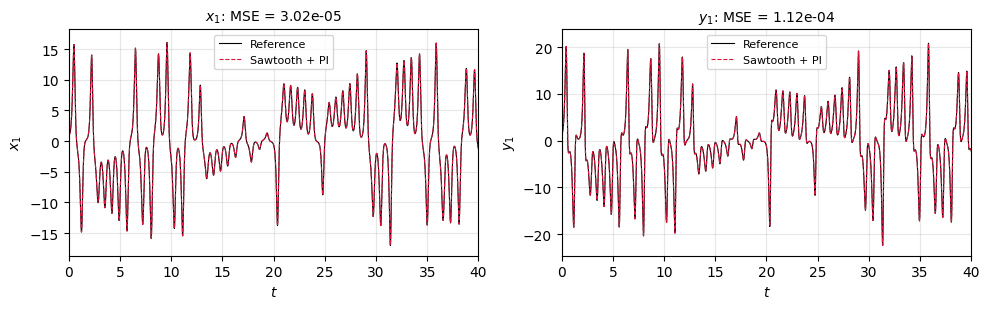

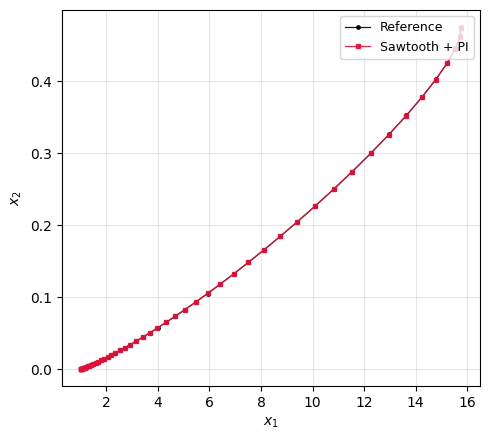


Saved files:
  fig1_complex_lorenz.png       - synchronization (x1, y1)
  fig2_complex_lorenz_phase.png - phase portrait (first 50 samples)


In [14]:
# ======================================================================
# FIG. 1: Complex Lorenz system - synchronization (sawtooth + PI)
# ======================================================================
from scipy.interpolate import interp1d
from scipy.signal import sawtooth
import matplotlib.pyplot as plt

# --- reference interpolators ---
x1_ref_f = interp1d(t, X[:, 0], fill_value='extrapolate')
x2_ref_f = interp1d(t, X[:, 1], fill_value='extrapolate')
y1_ref_f = interp1d(t, X[:, 2], fill_value='extrapolate')
y2_ref_f = interp1d(t, X[:, 3], fill_value='extrapolate')
z_ref_f  = interp1d(t, X[:, 4], fill_value='extrapolate')

A_saw, f_saw = 0.01, 0.1
Kp, Ki = 20.0, 1.0

def u_saw(t):
    return A_saw * sawtooth(2 * np.pi * f_saw * t)

def closed_loop_rhs(t, state):
    x1, x2, y1, y2, z = state[:5]
    q = state[5:10]
    x1 = np.clip(x1, -50, 50); x2 = np.clip(x2, -50, 50)
    y1 = np.clip(y1, -50, 50); y2 = np.clip(y2, -50, 50)
    z  = np.clip(z, -10, 100)

    phi_eq = basis_eq(x1, x2, y1, y2, z)
    phi_inv = basis_inv(x1, x2, y1, y2, z)
    dx = []
    for j, name in enumerate(['x1', 'x2', 'y1', 'y2', 'z']):
        c, c0 = coefs[name]
        phi = phi_eq if j < 4 else phi_inv
        dx.append(np.dot(c, phi) + c0)

    refs = [x1_ref_f(t), x2_ref_f(t), y1_ref_f(t), y2_ref_f(t), z_ref_f(t)]
    current = [x1, x2, y1, y2, z]
    err = np.array([refs[i] - current[i] for i in range(5)])
    u_pi = Kp * err + Ki * q

    u = u_pi.copy()
    u[0] += u_saw(t)

    dstate = np.zeros(10)
    for j in range(5):
        dstate[j] = dx[j] + u[j]
    dstate[5:10] = err
    return dstate

state0_ctrl = np.concatenate([X[0], np.zeros(5)])
sol_ctrl = solve_ivp(closed_loop_rhs, (t[0], t[-1]), state0_ctrl,
                     t_eval=t, method='BDF',
                     rtol=1e-5, atol=1e-8, max_step=0.5)
X_ctrl = sol_ctrl.y[:5].T

print("\nTracking MSE (sawtooth + PI):")
mse_ctrl = {}
for j, name in enumerate(['x1', 'x2', 'y1', 'y2', 'z']):
    mse_ctrl[name] = np.mean((X[:, j] - X_ctrl[:, j])**2)
    print(f"  {name}: {mse_ctrl[name]:.3e}")


# ----------------------------------------------------------------------
# FIG. 1: two-panel time series (x1, y1) - synchronization
# ----------------------------------------------------------------------
fig1, axes = plt.subplots(1, 2, figsize=(10, 3.2))

ax = axes[0]
ax.plot(t, X[:, 0], lw=0.8, color='black', label='Reference')
ax.plot(t, X_ctrl[:, 0], '--', lw=0.8, color='crimson',
        label='Sawtooth + PI')
ax.set_xlabel('$t$'); ax.set_ylabel('$x_1$')
ax.set_title(f'$x_1$: MSE = {mse_ctrl["x1"]:.2e}', fontsize=10)
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
ax.set_xlim(0, 40)

ax = axes[1]
ax.plot(t, X[:, 2], lw=0.8, color='black', label='Reference')
ax.plot(t, X_ctrl[:, 2], '--', lw=0.8, color='crimson',
        label='Sawtooth + PI')
ax.set_xlabel('$t$'); ax.set_ylabel('$y_1$')
ax.set_title(f'$y_1$: MSE = {mse_ctrl["y1"]:.2e}', fontsize=10)
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
ax.set_xlim(0, 40)

plt.tight_layout()
plt.savefig('fig1_complex_lorenz.png', dpi=300, bbox_inches='tight')
plt.show()


# ----------------------------------------------------------------------
# FIG. 2: phase portrait (x1, x2) - first 50 samples
# ----------------------------------------------------------------------
n_phase = 50

fig2, ax = plt.subplots(1, 1, figsize=(5, 4.5))

ax.plot(X[:n_phase, 0], X[:n_phase, 1], lw=0.9, alpha=0.9,
        color='black', marker='o', ms=2.5, label='Reference')
ax.plot(X_ctrl[:n_phase, 0], X_ctrl[:n_phase, 1], lw=0.9, alpha=0.9,
        color='crimson', marker='s', ms=2.5, label='Sawtooth + PI')
ax.set_xlabel('$x_1$'); ax.set_ylabel('$x_2$')
ax.legend(fontsize=9, loc='upper right')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('fig2_complex_lorenz_phase.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nSaved files:")
print("  fig1_complex_lorenz.png       - synchronization (x1, y1)")
print("  fig2_complex_lorenz_phase.png - phase portrait (first 50 samples)")


Tracking MSE (controlled, sawtooth + PI):
  x1: 3.016e-05
  x2: 2.341e-05
  y1: 1.125e-04
  y2: 8.801e-05
  z: 1.722e-04

Autonomous system (no controller):
  x1: MSE vs reference = 6.395e+01
  x2: MSE vs reference = 6.023e+01
  y1: MSE vs reference = 8.349e+01
  y2: MSE vs reference = 7.960e+01
  z: MSE vs reference = 1.493e+02


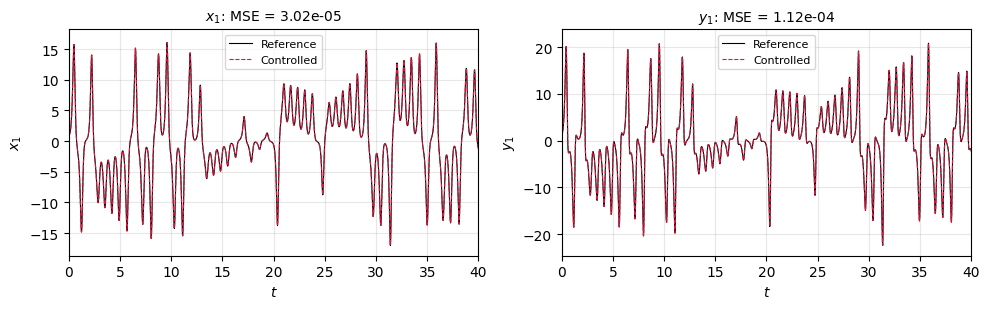

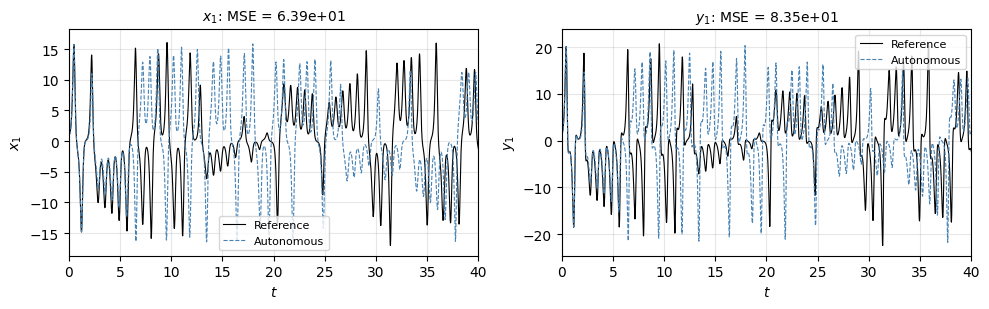

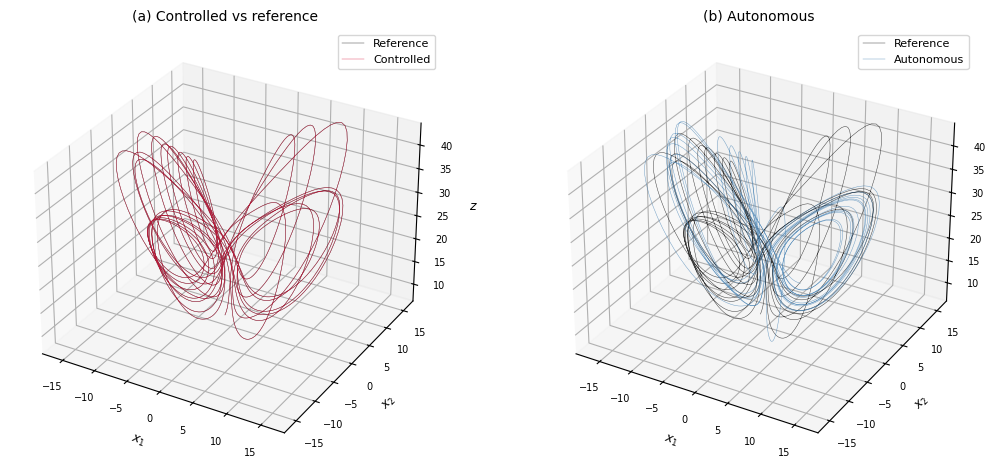


Saved files:
  fig1_controlled_dynamics.png  - controlled system dynamics
  fig2_autonomous_dynamics.png  - autonomous system dynamics
  fig3_attractors_3d.png        - 3D attractors side by side


In [15]:
# ======================================================================
# Complex Lorenz system: three figures for the paper
#   1) dynamics of the controlled system
#   2) dynamics of the autonomous (free-running) system
#   3) 3D attractors: controlled (matches reference) vs autonomous
# ======================================================================
from scipy.interpolate import interp1d
from scipy.signal import sawtooth
import matplotlib.pyplot as plt

# Coefficients were identified ONCE in the previous cell (coefs dict).
# All three figures reuse them — no re-identification happens.

# --- reference interpolators ---
x1_ref_f = interp1d(t, X[:, 0], fill_value='extrapolate')
x2_ref_f = interp1d(t, X[:, 1], fill_value='extrapolate')
y1_ref_f = interp1d(t, X[:, 2], fill_value='extrapolate')
y2_ref_f = interp1d(t, X[:, 3], fill_value='extrapolate')
z_ref_f  = interp1d(t, X[:, 4], fill_value='extrapolate')

A_saw, f_saw = 0.01, 0.1
Kp, Ki = 20.0, 1.0

def u_saw(t):
    return A_saw * sawtooth(2 * np.pi * f_saw * t)

# ----------------------------------------------------------------------
# Controlled system: response + PI controller + sawtooth
# ----------------------------------------------------------------------
def closed_loop_rhs(t, state):
    x1, x2, y1, y2, z = state[:5]
    q = state[5:10]
    x1 = np.clip(x1, -50, 50); x2 = np.clip(x2, -50, 50)
    y1 = np.clip(y1, -50, 50); y2 = np.clip(y2, -50, 50)
    z  = np.clip(z, -10, 100)

    phi_eq = basis_eq(x1, x2, y1, y2, z)
    phi_inv = basis_inv(x1, x2, y1, y2, z)
    dx = []
    for j, name in enumerate(['x1', 'x2', 'y1', 'y2', 'z']):
        c, c0 = coefs[name]
        phi = phi_eq if j < 4 else phi_inv
        dx.append(np.dot(c, phi) + c0)

    refs = [x1_ref_f(t), x2_ref_f(t), y1_ref_f(t), y2_ref_f(t), z_ref_f(t)]
    current = [x1, x2, y1, y2, z]
    err = np.array([refs[i] - current[i] for i in range(5)])
    u_pi = Kp * err + Ki * q

    u = u_pi.copy()
    u[0] += u_saw(t)

    dstate = np.zeros(10)
    dstate[:5] = np.array(dx) + u
    dstate[5:10] = err
    return dstate

state0_ctrl = np.concatenate([X[0], np.zeros(5)])
sol_ctrl = solve_ivp(closed_loop_rhs, (t[0], t[-1]), state0_ctrl,
                     t_eval=t, method='BDF',
                     rtol=1e-5, atol=1e-8, max_step=0.5)
X_ctrl = sol_ctrl.y[:5].T

print("\nTracking MSE (controlled, sawtooth + PI):")
mse_ctrl = {}
for j, name in enumerate(['x1', 'x2', 'y1', 'y2', 'z']):
    mse_ctrl[name] = np.mean((X[:, j] - X_ctrl[:, j])**2)
    print(f"  {name}: {mse_ctrl[name]:.3e}")

# ----------------------------------------------------------------------
# Autonomous system: same recovered model, no controller
# ----------------------------------------------------------------------
sol_auto = solve_ivp(lambda tt, s: F_model(s), (t[0], t[-1]), X[0],
                     t_eval=t, method='LSODA',
                     rtol=1e-8, atol=1e-10)
X_auto = sol_auto.y.T
n_auto = min(len(X_auto), len(X))

print("\nAutonomous system (no controller):")
for j, name in enumerate(['x1', 'x2', 'y1', 'y2', 'z']):
    mse = np.mean((X[:n_auto, j] - X_auto[:n_auto, j])**2)
    print(f"  {name}: MSE vs reference = {mse:.3e}")


# ======================================================================
# FIG. 1: dynamics of the controlled system (x1, y1)
# ======================================================================
fig1, axes = plt.subplots(1, 2, figsize=(10, 3.2))

ax = axes[0]
ax.plot(t, X[:, 0], lw=0.8, color='black', label='Reference')
ax.plot(t, X_ctrl[:, 0], '--', lw=0.8, color='crimson',
        label='Controlled')
ax.set_xlabel('$t$'); ax.set_ylabel('$x_1$')
ax.set_title(f'$x_1$: MSE = {mse_ctrl["x1"]:.2e}', fontsize=10)
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
ax.set_xlim(0, 40)

ax = axes[1]
ax.plot(t, X[:, 2], lw=0.8, color='black', label='Reference')
ax.plot(t, X_ctrl[:, 2], '--', lw=0.8, color='crimson',
        label='Controlled')
ax.set_xlabel('$t$'); ax.set_ylabel('$y_1$')
ax.set_title(f'$y_1$: MSE = {mse_ctrl["y1"]:.2e}', fontsize=10)
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
ax.set_xlim(0, 40)

plt.tight_layout()
plt.savefig('fig1_controlled_dynamics.png', dpi=300, bbox_inches='tight')
plt.show()


# ======================================================================
# FIG. 2: dynamics of the autonomous system (x1, y1)
# ======================================================================
fig2, axes = plt.subplots(1, 2, figsize=(10, 3.2))

ax = axes[0]
ax.plot(t[:n_auto], X[:n_auto, 0], lw=0.8, color='black',
        label='Reference')
ax.plot(t[:n_auto], X_auto[:n_auto, 0], '--', lw=0.8, color='steelblue',
        label='Autonomous')
ax.set_xlabel('$t$'); ax.set_ylabel('$x_1$')
mse_x1_auto = np.mean((X[:n_auto, 0] - X_auto[:n_auto, 0])**2)
ax.set_title(f'$x_1$: MSE = {mse_x1_auto:.2e}', fontsize=10)
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
ax.set_xlim(0, 40)

ax = axes[1]
ax.plot(t[:n_auto], X[:n_auto, 2], lw=0.8, color='black',
        label='Reference')
ax.plot(t[:n_auto], X_auto[:n_auto, 2], '--', lw=0.8, color='steelblue',
        label='Autonomous')
ax.set_xlabel('$t$'); ax.set_ylabel('$y_1$')
mse_y1_auto = np.mean((X[:n_auto, 2] - X_auto[:n_auto, 2])**2)
ax.set_title(f'$y_1$: MSE = {mse_y1_auto:.2e}', fontsize=10)
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
ax.set_xlim(0, 40)

plt.tight_layout()
plt.savefig('fig2_autonomous_dynamics.png', dpi=300, bbox_inches='tight')
plt.show()


# ======================================================================
# FIG. 3: two 3D attractors side by side
#   left  — controlled system vs reference (indistinguishable)
#   right — autonomous system (chaos persists without controller)
# ======================================================================
from mpl_toolkits.mplot3d import Axes3D   # noqa: F401

n_phase = 2000   # first 20 s at dt = 0.01

fig3 = plt.figure(figsize=(11, 4.8))

# --- (a) controlled vs reference ---
ax = fig3.add_subplot(1, 2, 1, projection='3d')
ax.plot(X[:n_phase, 0], X[:n_phase, 1], X[:n_phase, 4],
        lw=0.35, alpha=0.75, color='black', label='Reference')
ax.plot(X_ctrl[:n_phase, 0], X_ctrl[:n_phase, 1], X_ctrl[:n_phase, 4],
        lw=0.35, alpha=0.75, color='crimson', label='Controlled')
ax.set_xlabel('$x_1$', fontsize=9)
ax.set_ylabel('$x_2$', fontsize=9)
ax.set_zlabel('$z$', fontsize=9)
ax.set_title('(a) Controlled vs reference', fontsize=10)
ax.legend(fontsize=8, loc='upper right')
ax.tick_params(labelsize=7)

# --- (b) autonomous ---
ax = fig3.add_subplot(1, 2, 2, projection='3d')
ax.plot(X[:n_phase, 0], X[:n_phase, 1], X[:n_phase, 4],
        lw=0.35, alpha=0.75, color='black', label='Reference')
ax.plot(X_auto[:n_phase, 0], X_auto[:n_phase, 1], X_auto[:n_phase, 4],
        lw=0.35, alpha=0.75, color='steelblue', label='Autonomous')
ax.set_xlabel('$x_1$', fontsize=9)
ax.set_ylabel('$x_2$', fontsize=9)
ax.set_zlabel('$z$', fontsize=9)
ax.set_title('(b) Autonomous', fontsize=10)
ax.legend(fontsize=8, loc='upper right')
ax.tick_params(labelsize=7)

plt.tight_layout()
plt.savefig('fig3_attractors_3d.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nSaved files:")
print("  fig1_controlled_dynamics.png  - controlled system dynamics")
print("  fig2_autonomous_dynamics.png  - autonomous system dynamics")
print("  fig3_attractors_3d.png        - 3D attractors side by side")

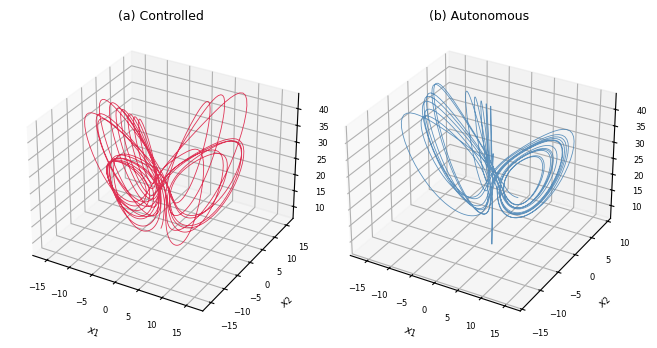


Saved: fig3_attractors_3d.png (single trajectory per panel)


In [18]:
# ======================================================================
# FIG. 3: two 3D attractors side by side (single column)
#   left  — controlled trajectory (coincides with reference)
#   right — autonomous trajectory (chaos persists without controller)
# ======================================================================
from mpl_toolkits.mplot3d import Axes3D   # noqa: F401

n_phase = 2000   # first 20 s at dt = 0.01

fig3 = plt.figure(figsize=(6.5, 3.6))

# --- (a) controlled ---
ax1 = fig3.add_subplot(1, 2, 1, projection='3d')
ax1.plot(X_ctrl[:n_phase, 0], X_ctrl[:n_phase, 1], X_ctrl[:n_phase, 4],
         lw=0.6, alpha=0.85, color='crimson')
ax1.set_xlabel('$x_1$', fontsize=8)
ax1.set_ylabel('$x_2$', fontsize=8)
ax1.set_zlabel('$z$', fontsize=8)
ax1.set_title('(a) Controlled', fontsize=9)
ax1.tick_params(labelsize=6)

# --- (b) autonomous ---
ax2 = fig3.add_subplot(1, 2, 2, projection='3d')
ax2.plot(X_auto[:n_phase, 0], X_auto[:n_phase, 1], X_auto[:n_phase, 4],
         lw=0.6, alpha=0.85, color='steelblue')
ax2.set_xlabel('$x_1$', fontsize=8)
ax2.set_ylabel('$x_2$', fontsize=8)
ax2.set_zlabel('$z$', fontsize=8)
ax2.set_title('(b) Autonomous', fontsize=9)
ax2.tick_params(labelsize=6)

plt.tight_layout()
plt.savefig('fig3_attractors_3d.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nSaved: fig3_attractors_3d.png (single trajectory per panel)")


Tracking MSE (sawtooth + PI):
  x1: 3.016e-05
  x2: 2.341e-05
  y1: 1.125e-04
  y2: 8.801e-05
  z: 1.722e-04


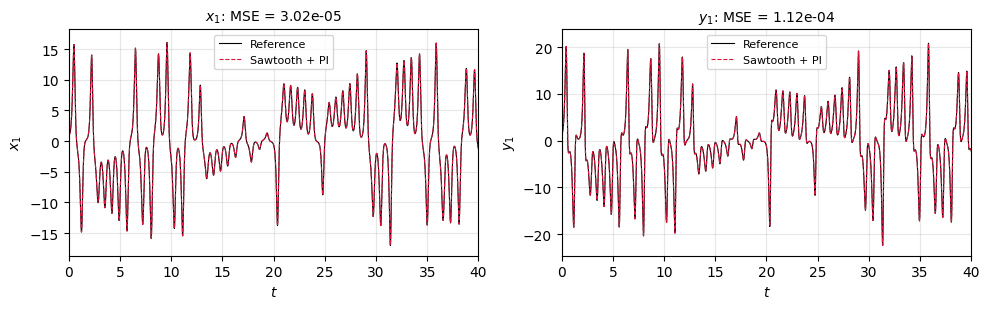

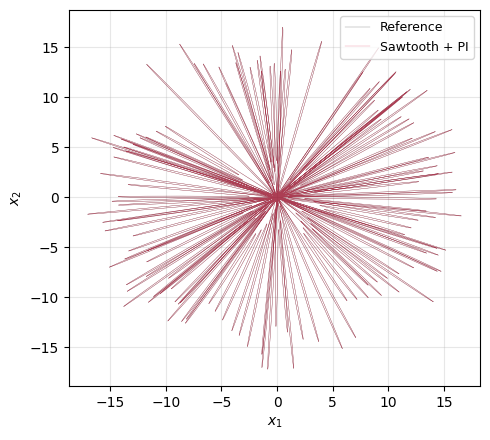

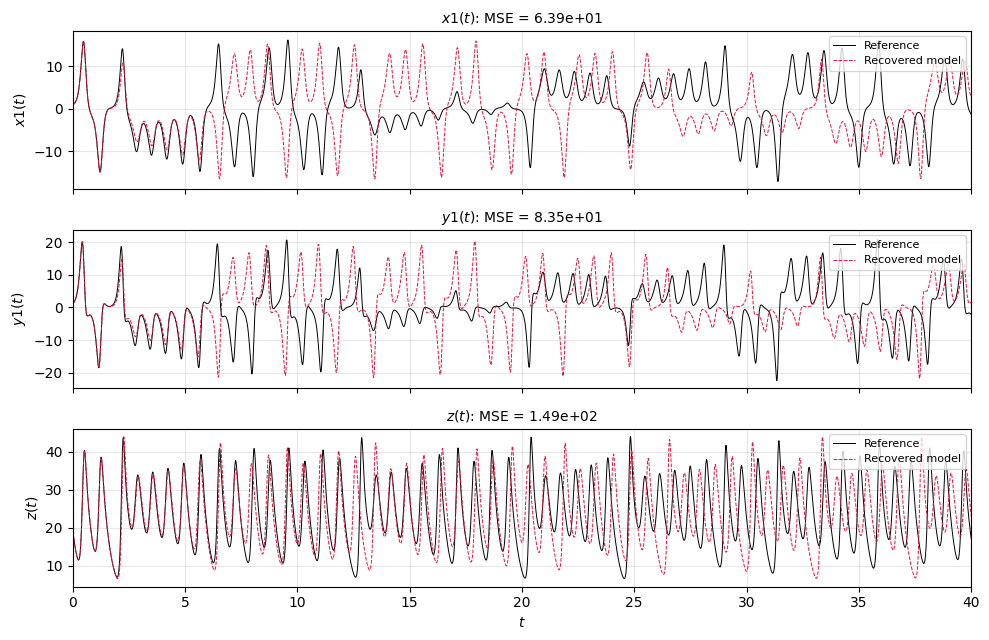


Saved files:
  fig1_complex_lorenz.png       - synchronization (x1, y1)
  fig2_complex_lorenz_phase.png - phase portrait (x1, x2)
  fig3_complex_lorenz_model.png - free integration (supplementary)


In [12]:
# ======================================================================
# FIG. 1: Complex Lorenz system - synchronization (sawtooth + PI)
# Compact two-panel version: x1 and y1 time series
# ======================================================================
from scipy.interpolate import interp1d
from scipy.signal import sawtooth
import matplotlib.pyplot as plt

# --- reference interpolators ---
x1_ref_f = interp1d(t, X[:, 0], fill_value='extrapolate')
x2_ref_f = interp1d(t, X[:, 1], fill_value='extrapolate')
y1_ref_f = interp1d(t, X[:, 2], fill_value='extrapolate')
y2_ref_f = interp1d(t, X[:, 3], fill_value='extrapolate')
z_ref_f  = interp1d(t, X[:, 4], fill_value='extrapolate')

A_saw, f_saw = 0.01, 0.1
Kp, Ki = 20.0, 1.0

def u_saw(t):
    return A_saw * sawtooth(2 * np.pi * f_saw * t)

def closed_loop_rhs(t, state):
    x1, x2, y1, y2, z = state[:5]
    q = state[5:10]
    x1 = np.clip(x1, -50, 50); x2 = np.clip(x2, -50, 50)
    y1 = np.clip(y1, -50, 50); y2 = np.clip(y2, -50, 50)
    z  = np.clip(z, -10, 100)

    phi_eq = basis_eq(x1, x2, y1, y2, z)
    phi_inv = basis_inv(x1, x2, y1, y2, z)
    dx = []
    for j, name in enumerate(['x1', 'x2', 'y1', 'y2', 'z']):
        c, c0 = coefs[name]
        phi = phi_eq if j < 4 else phi_inv
        dx.append(np.dot(c, phi) + c0)

    refs = [x1_ref_f(t), x2_ref_f(t), y1_ref_f(t), y2_ref_f(t), z_ref_f(t)]
    current = [x1, x2, y1, y2, z]
    err = np.array([refs[i] - current[i] for i in range(5)])
    u_pi = Kp * err + Ki * q

    u = u_pi.copy()
    u[0] += u_saw(t)

    dstate = np.zeros(10)
    for j in range(5):
        dstate[j] = dx[j] + u[j]
    dstate[5:10] = err
    return dstate

state0_ctrl = np.concatenate([X[0], np.zeros(5)])
sol_ctrl = solve_ivp(closed_loop_rhs, (t[0], t[-1]), state0_ctrl,
                     t_eval=t, method='BDF',
                     rtol=1e-5, atol=1e-8, max_step=0.5)
X_ctrl = sol_ctrl.y[:5].T

print("\nTracking MSE (sawtooth + PI):")
mse_ctrl = {}
for j, name in enumerate(['x1', 'x2', 'y1', 'y2', 'z']):
    mse_ctrl[name] = np.mean((X[:, j] - X_ctrl[:, j])**2)
    print(f"  {name}: {mse_ctrl[name]:.3e}")

# ----------------------------------------------------------------------
# FIG. 1a: two-panel time series (x1, y1) - for the main text
# ----------------------------------------------------------------------
fig1, axes = plt.subplots(1, 2, figsize=(10, 3.2))

ax = axes[0]
ax.plot(t, X[:, 0], lw=0.8, color='black', label='Reference')
ax.plot(t, X_ctrl[:, 0], '--', lw=0.8, color='crimson',
        label='Sawtooth + PI')
ax.set_xlabel('$t$'); ax.set_ylabel('$x_1$')
ax.set_title(f'$x_1$: MSE = {mse_ctrl["x1"]:.2e}', fontsize=10)
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
ax.set_xlim(0, 40)

ax = axes[1]
ax.plot(t, X[:, 2], lw=0.8, color='black', label='Reference')
ax.plot(t, X_ctrl[:, 2], '--', lw=0.8, color='crimson',
        label='Sawtooth + PI')
ax.set_xlabel('$t$'); ax.set_ylabel('$y_1$')
ax.set_title(f'$y_1$: MSE = {mse_ctrl["y1"]:.2e}', fontsize=10)
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
ax.set_xlim(0, 40)

plt.tight_layout()
plt.savefig('fig1_complex_lorenz.png', dpi=300, bbox_inches='tight')
plt.show()


# ----------------------------------------------------------------------
# FIG. 1b: phase portrait (x1, x2) - for the main text
# ----------------------------------------------------------------------
fig1b, ax = plt.subplots(1, 1, figsize=(5, 4.5))

ax.plot(X[:, 0], X[:, 1], lw=0.25, alpha=0.55,
        color='black', label='Reference')
ax.plot(X_ctrl[:, 0], X_ctrl[:, 1], lw=0.25, alpha=0.55,
        color='crimson', label='Sawtooth + PI')
ax.set_xlabel('$x_1$'); ax.set_ylabel('$x_2$')
ax.legend(fontsize=9, loc='upper right')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('fig2_complex_lorenz_phase.png', dpi=300, bbox_inches='tight')
plt.show()


# ======================================================================
# FIG. 2 (supplementary): free integration of the recovered model
# ======================================================================
sol_model = solve_ivp(lambda tt, s: F_model(s), (t[0], t[-1]), X[0],
                      t_eval=t, method='LSODA',
                      rtol=1e-8, atol=1e-10)
t_m = sol_model.t
X_m = sol_model.y.T
n_m = min(len(t_m), len(t))

fig2, axes = plt.subplots(3, 1, figsize=(10, 6.5), sharex=True)

for k, (j, name) in enumerate([(0, 'x1'), (2, 'y1'), (4, 'z')]):
    ax = axes[k]
    ax.plot(t[:n_m], X[:n_m, j], lw=0.7, color='black', label='Reference')
    ax.plot(t_m[:n_m], X_m[:n_m, j], '--', lw=0.7, color='crimson',
            label='Recovered model')
    mse = np.mean((X[:n_m, j] - X_m[:n_m, j])**2)
    ax.set_ylabel(f'${name}(t)$')
    ax.set_title(f'${name}(t)$: MSE = {mse:.2e}', fontsize=10)
    ax.legend(fontsize=8, loc='upper right'); ax.grid(True, alpha=0.3)
    ax.set_xlim(0, 40)

axes[-1].set_xlabel('$t$')

plt.tight_layout()
plt.savefig('fig3_complex_lorenz_model.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nSaved files:")
print("  fig1_complex_lorenz.png       - synchronization (x1, y1)")
print("  fig2_complex_lorenz_phase.png - phase portrait (x1, x2)")
print("  fig3_complex_lorenz_model.png - free integration (supplementary)")

RABINOVICH SYSTEM: switch + PD
Reference amplitudes (hidden attractor):
  x: min =   -21.500, max =    27.100, std = 3.959
  y: min =   -87.000, max =    94.865, std = 6.901
  z: min =     0.000, max =   190.978, std = 7.011

Identification MSE:
  dx/dt: 1.466e-06
  dy/dt: 2.887e-05
  dz/dt: 1.495e-04

Tracking MSE (switch + PD):
  x: 0.000552
  y: 0.000344
  z: 0.000130

Autonomous system (no controller):
  x: MSE vs reference = 3.206e+01
  y: MSE vs reference = 5.617e+01
  z: MSE vs reference = 4.542e+01


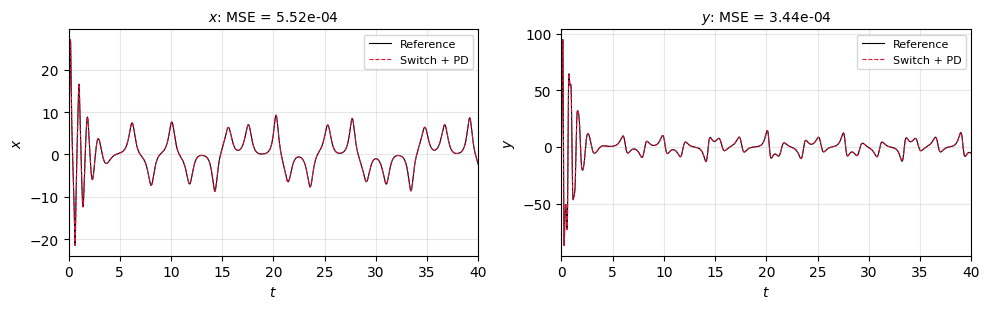

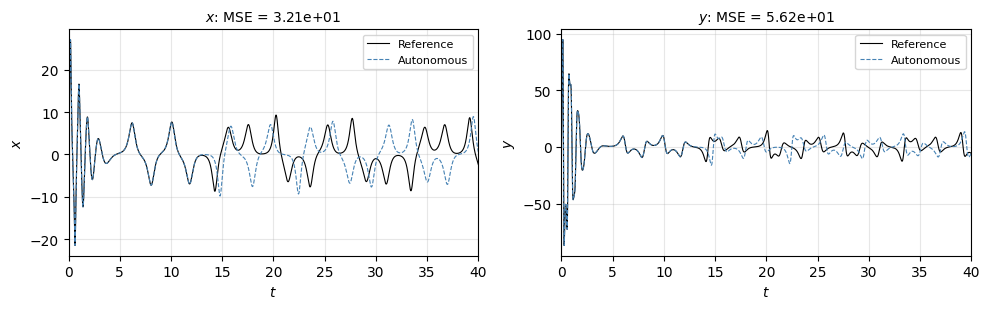

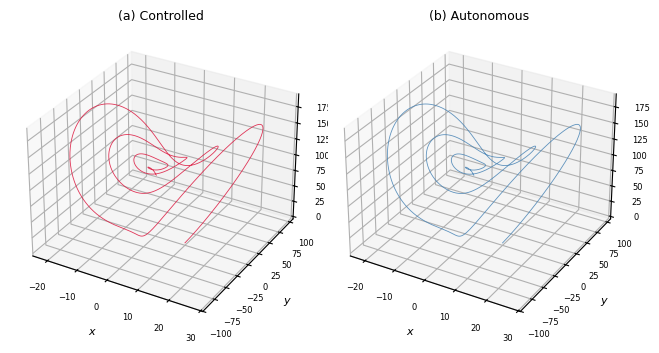


DONE. Saved files:
  fig1_rabinovich_controlled.png  - controlled dynamics
  fig2_rabinovich_autonomous.png  - autonomous dynamics
  fig3_rabinovich_attractors.png  - 3D attractors


In [19]:
# ======================================================================
# FIGURES: RABINOVICH SYSTEM (Z2)
# Three compact figures for the paper
#   1) controlled dynamics (x, y)
#   2) autonomous dynamics (x, y)
#   3) 3D attractors: controlled vs autonomous
# ======================================================================
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.interpolate import interp1d
from sklearn.linear_model import RidgeCV
from sklearn.preprocessing import StandardScaler

def deriv(y, dt):
    d = np.zeros_like(y)
    d[1:-1] = (y[2:] - y[:-2]) / (2 * dt)
    d[0] = (y[1] - y[0]) / dt
    d[-1] = (y[-1] - y[-2]) / dt
    return d

# ======================================================================
# 1. Reference trajectory (hidden attractor)
# ======================================================================
r_rb = 100.0
a_rb = -0.009965
b_rb = 0.077454
sigma_rb = -a_rb * r_rb

def rabinovich(t, state):
    x, y, z = state
    return np.array([
        -sigma_rb * (x - y) - a_rb * y * z,
         r_rb * x - y - x * z,
        -b_rb * z + x * y,
    ])

dt_rb = 0.001
t_rb = np.arange(0, 200, dt_rb)
N_rb = len(t_rb)
x0_rb = [10.0, 0.0, 0.0]

sol_rb = solve_ivp(rabinovich, (0, 200), x0_rb,
                    t_eval=t_rb, method='LSODA', rtol=1e-10, atol=1e-12)
X_rb = sol_rb.y.T

print("=" * 72)
print("RABINOVICH SYSTEM: switch + PD")
print("=" * 72)
print("Reference amplitudes (hidden attractor):")
for j, name in enumerate(['x', 'y', 'z']):
    print(f"  {name}: min = {X_rb[:,j].min():9.3f}, "
          f"max = {X_rb[:,j].max():9.3f}, std = {X_rb[:,j].std():.3f}")

# ======================================================================
# 2. Minimal Z2 basis (Weyl's theorem)
# ======================================================================
def basis_x_rb(x, y, z):
    return np.array([x, y, y*z])

def basis_y_rb(x, y, z):
    return np.array([x, y, x*z])

def basis_z_rb(x, y, z):
    return np.array([1.0, z, x*y])

Phi_x_rb = np.array([basis_x_rb(*X_rb[i]) for i in range(N_rb)])
Phi_y_rb = np.array([basis_y_rb(*X_rb[i]) for i in range(N_rb)])
Phi_z_rb = np.array([basis_z_rb(*X_rb[i]) for i in range(N_rb)])
dX_rb = np.column_stack([deriv(X_rb[:, j], dt_rb) for j in range(3)])

# ======================================================================
# 3. Identification
# ======================================================================
coefs_rb = {}
print("\nIdentification MSE:")
for Phi, dXi, name in [(Phi_x_rb, dX_rb[:, 0], 'x'),
                        (Phi_y_rb, dX_rb[:, 1], 'y'),
                        (Phi_z_rb, dX_rb[:, 2], 'z')]:
    scaler = StandardScaler()
    Phi_s = scaler.fit_transform(Phi)
    ridge = RidgeCV(alphas=np.logspace(-6, 2, 30))
    ridge.fit(Phi_s, dXi)
    mse = np.mean((dXi - ridge.predict(Phi_s))**2)
    coefs_rb[name] = (scaler, ridge)
    print(f"  d{name}/dt: {mse:.3e}")

# ======================================================================
# 4. Right-hand side of the recovered model
# ======================================================================
def F_rb_rhs(state):
    x, y, z = state
    x = np.clip(x, -200, 200); y = np.clip(y, -200, 200)
    z = np.clip(z, -50, 300)
    scaler_x, ridge_x = coefs_rb['x']
    scaler_y, ridge_y = coefs_rb['y']
    scaler_z, ridge_z = coefs_rb['z']
    fx = float(((basis_x_rb(x, y, z) - scaler_x.mean_) / scaler_x.scale_)
               @ ridge_x.coef_ + ridge_x.intercept_)
    fy = float(((basis_y_rb(x, y, z) - scaler_y.mean_) / scaler_y.scale_)
               @ ridge_y.coef_ + ridge_y.intercept_)
    fz = float(((basis_z_rb(x, y, z) - scaler_z.mean_) / scaler_z.scale_)
               @ ridge_z.coef_ + ridge_z.intercept_)
    return np.array([fx, fy, fz])

# ======================================================================
# 5. Control: switch + PD controller
# ======================================================================
x_ref_f = interp1d(t_rb, X_rb[:, 0], fill_value='extrapolate')
y_ref_f = interp1d(t_rb, X_rb[:, 1], fill_value='extrapolate')
z_ref_f = interp1d(t_rb, X_rb[:, 2], fill_value='extrapolate')

xdot_ref_f = interp1d(t_rb, deriv(X_rb[:, 0], dt_rb), fill_value='extrapolate')
ydot_ref_f = interp1d(t_rb, deriv(X_rb[:, 1], dt_rb), fill_value='extrapolate')
zdot_ref_f = interp1d(t_rb, deriv(X_rb[:, 2], dt_rb), fill_value='extrapolate')

A_sw = 1.0
T_sw = 25.0
Kp_pd = 50.0
Kd_pd = 5.0

def u_switch(t):
    return A_sw if (t % T_sw) < T_sw/2 else -A_sw

def closed_loop_rhs(t, state):
    x, y, z = state[:3]
    dx_base = F_rb_rhs([x, y, z])

    refs = np.array([x_ref_f(t), y_ref_f(t), z_ref_f(t)])
    drefs = np.array([xdot_ref_f(t), ydot_ref_f(t), zdot_ref_f(t)])
    current = np.array([x, y, z])

    errors = refs - current
    derrors = drefs - dx_base

    u_pd = Kp_pd * errors + Kd_pd * derrors

    u = u_pd.copy()
    u[0] += u_switch(t)

    return dx_base + u

state0 = np.array(X_rb[0])
sol_ctrl = solve_ivp(closed_loop_rhs, (0, 200), state0,
                     t_eval=t_rb, method='BDF',
                     rtol=1e-5, atol=1e-8, max_step=0.5)
X_ctrl = sol_ctrl.y.T

print("\nTracking MSE (switch + PD):")
mse_ctrl = {}
for j, name in enumerate(['x', 'y', 'z']):
    mse = np.mean((X_rb[:, j] - X_ctrl[:, j])**2)
    mse_ctrl[name] = mse
    print(f"  {name}: {mse:.6f}")

# ======================================================================
# 6. Autonomous system: same recovered model, no controller
# ======================================================================
sol_auto = solve_ivp(lambda tt, s: F_rb_rhs(s), (0, 200), X_rb[0],
                     t_eval=t_rb, method='LSODA',
                     rtol=1e-8, atol=1e-10)
X_auto = sol_auto.y.T

print("\nAutonomous system (no controller):")
for j, name in enumerate(['x', 'y', 'z']):
    mse = np.mean((X_rb[:, j] - X_auto[:, j])**2)
    print(f"  {name}: MSE vs reference = {mse:.3e}")


# ======================================================================
# FIG. 1: dynamics of the controlled system (x, y)
# ======================================================================
fig1, axes = plt.subplots(1, 2, figsize=(10, 3.2))

ax = axes[0]
ax.plot(t_rb, X_rb[:, 0], lw=0.8, color='black', label='Reference')
ax.plot(t_rb, X_ctrl[:, 0], '--', lw=0.8, color='crimson',
        label='Switch + PD')
ax.set_xlabel('$t$'); ax.set_ylabel('$x$')
ax.set_title(f'$x$: MSE = {mse_ctrl["x"]:.2e}', fontsize=10)
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
ax.set_xlim(0, 40)

ax = axes[1]
ax.plot(t_rb, X_rb[:, 1], lw=0.8, color='black', label='Reference')
ax.plot(t_rb, X_ctrl[:, 1], '--', lw=0.8, color='crimson',
        label='Switch + PD')
ax.set_xlabel('$t$'); ax.set_ylabel('$y$')
ax.set_title(f'$y$: MSE = {mse_ctrl["y"]:.2e}', fontsize=10)
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
ax.set_xlim(0, 40)

plt.tight_layout()
plt.savefig('fig1_rabinovich_controlled.png', dpi=300, bbox_inches='tight')
plt.show()


# ======================================================================
# FIG. 2: dynamics of the autonomous system (x, y)
# ======================================================================
fig2, axes = plt.subplots(1, 2, figsize=(10, 3.2))

ax = axes[0]
ax.plot(t_rb, X_rb[:, 0], lw=0.8, color='black', label='Reference')
ax.plot(t_rb, X_auto[:, 0], '--', lw=0.8, color='steelblue',
        label='Autonomous')
ax.set_xlabel('$t$'); ax.set_ylabel('$x$')
mse_x_auto = np.mean((X_rb[:, 0] - X_auto[:, 0])**2)
ax.set_title(f'$x$: MSE = {mse_x_auto:.2e}', fontsize=10)
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
ax.set_xlim(0, 40)

ax = axes[1]
ax.plot(t_rb, X_rb[:, 1], lw=0.8, color='black', label='Reference')
ax.plot(t_rb, X_auto[:, 1], '--', lw=0.8, color='steelblue',
        label='Autonomous')
ax.set_xlabel('$t$'); ax.set_ylabel('$y$')
mse_y_auto = np.mean((X_rb[:, 1] - X_auto[:, 1])**2)
ax.set_title(f'$y$: MSE = {mse_y_auto:.2e}', fontsize=10)
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
ax.set_xlim(0, 40)

plt.tight_layout()
plt.savefig('fig2_rabinovich_autonomous.png', dpi=300, bbox_inches='tight')
plt.show()


# ======================================================================
# FIG. 3: two 3D attractors side by side (single column)
#   left  - controlled (coincides with reference)
#   right - autonomous (chaos persists without controller)
# ======================================================================
from mpl_toolkits.mplot3d import Axes3D   # noqa: F401

n_phase = 5000   # first 5 s at dt = 0.001

fig3 = plt.figure(figsize=(6.5, 3.6))

# --- (a) controlled ---
ax1 = fig3.add_subplot(1, 2, 1, projection='3d')
ax1.plot(X_ctrl[:n_phase, 0], X_ctrl[:n_phase, 1], X_ctrl[:n_phase, 2],
         lw=0.6, alpha=0.85, color='crimson')
ax1.set_xlabel('$x$', fontsize=8)
ax1.set_ylabel('$y$', fontsize=8)
ax1.set_zlabel('$z$', fontsize=8)
ax1.set_title('(a) Controlled', fontsize=9)
ax1.tick_params(labelsize=6)

# --- (b) autonomous ---
ax2 = fig3.add_subplot(1, 2, 2, projection='3d')
ax2.plot(X_auto[:n_phase, 0], X_auto[:n_phase, 1], X_auto[:n_phase, 2],
         lw=0.6, alpha=0.85, color='steelblue')
ax2.set_xlabel('$x$', fontsize=8)
ax2.set_ylabel('$y$', fontsize=8)
ax2.set_zlabel('$z$', fontsize=8)
ax2.set_title('(b) Autonomous', fontsize=9)
ax2.tick_params(labelsize=6)

plt.tight_layout()
plt.savefig('fig3_rabinovich_attractors.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n" + "=" * 72)
print("DONE. Saved files:")
print("  fig1_rabinovich_controlled.png  - controlled dynamics")
print("  fig2_rabinovich_autonomous.png  - autonomous dynamics")
print("  fig3_rabinovich_attractors.png  - 3D attractors")
print("=" * 72)

Mismatched pair, T = 200 s:
  x: MSE = 5.488e-02
  y: MSE = 5.904e-02
  z: MSE = 5.345e-02

MSE over time (windows):
  t in [  0,  25]: MSE = 5.900e-02
  t in [ 25,  50]: MSE = 5.483e-02
  t in [ 50, 100]: MSE = 5.544e-02
  t in [100, 150]: MSE = 5.535e-02
  t in [150, 200]: MSE = 5.545e-02


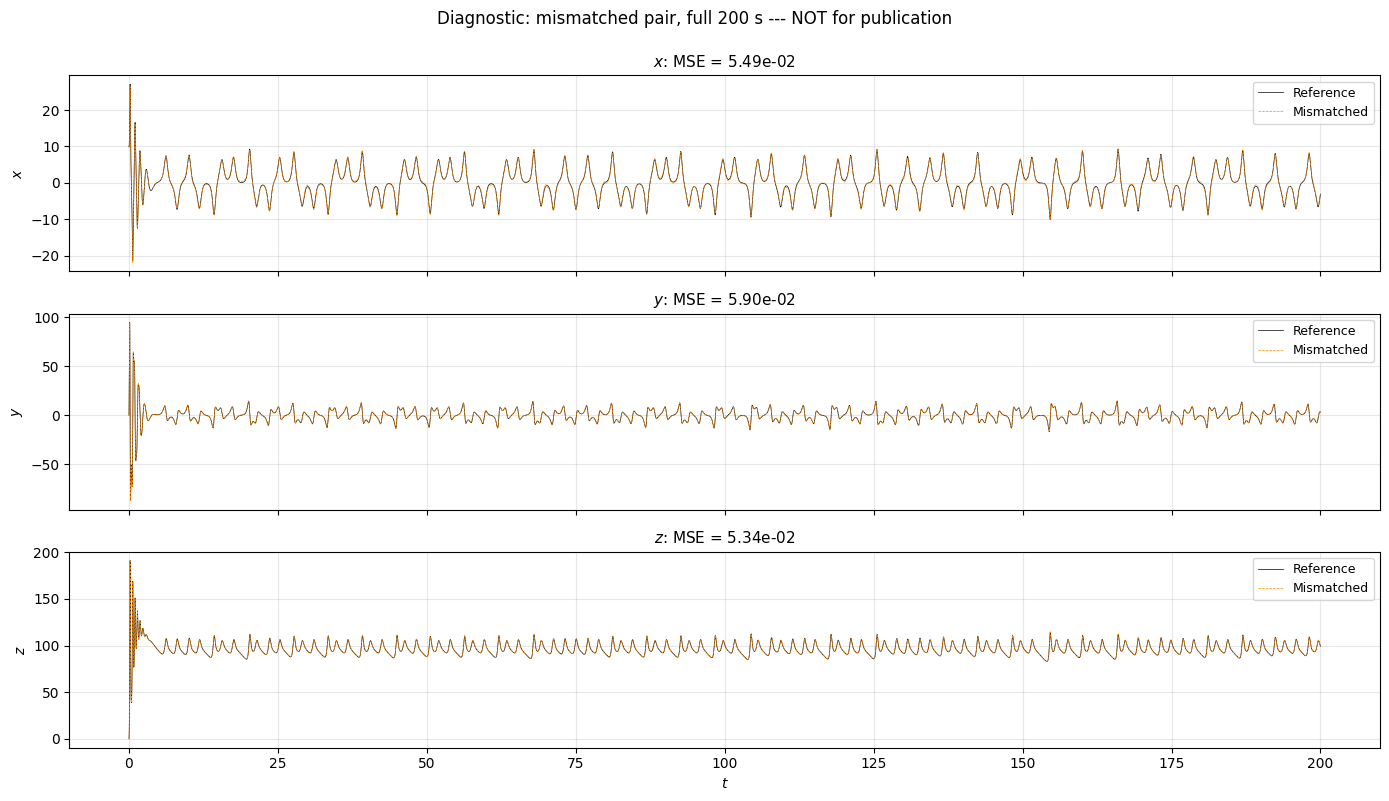

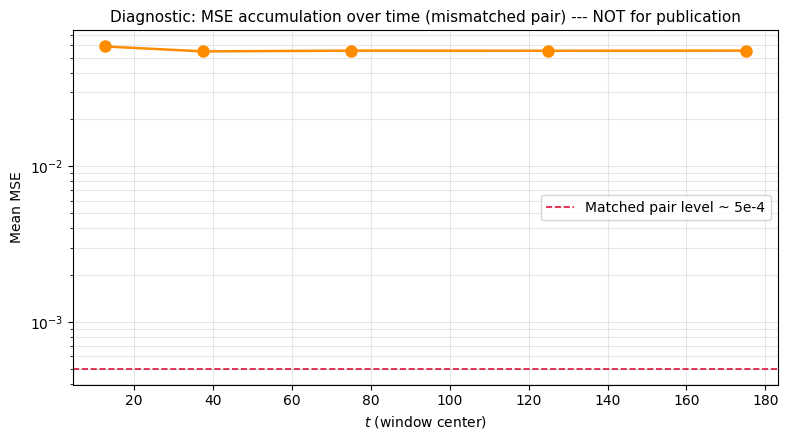

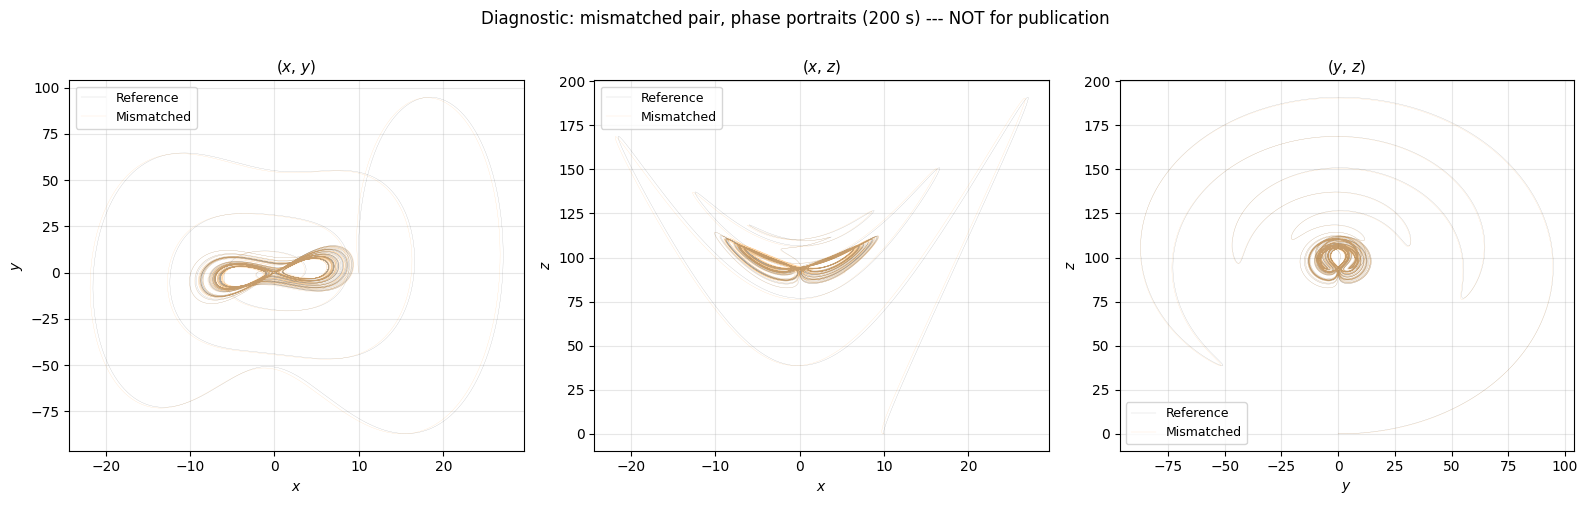


Saved diagnostic files:
  diag_rabinovich_mismatched_long.png       - time series (200 s)
  diag_rabinovich_mse_over_time.png         - MSE accumulation
  diag_rabinovich_mismatched_phase_long.png - phase portraits


In [22]:
# ======================================================================
# VISUAL CHECK: mismatched pair, extended interval T = 200 s
# Not for the paper - diagnostic plots only
# ======================================================================
from scipy.signal import sawtooth
import matplotlib.pyplot as plt

A_saw_rb, f_saw_rb = 20.0, 0.1

def u_saw_rb(t):
    return A_saw_rb * sawtooth(2 * np.pi * f_saw_rb * t)

def closed_loop_bad_rhs(t, state):
    x, y, z = state[:3]
    dx_base = F_rb_rhs([x, y, z])
    refs = np.array([x_ref_f(t), y_ref_f(t), z_ref_f(t)])
    current = np.array([x, y, z])
    err = refs - current
    u_pi = 50.0 * err
    u = u_pi.copy()
    u[0] += u_saw_rb(t)
    u[1] += u_saw_rb(t)
    u[2] += u_saw_rb(t)
    return dx_base + u

# --- extended interval: full 200 s ---
T_bad = 200.0
t_bad = np.arange(0, T_bad, dt_rb)

sol_bad = solve_ivp(closed_loop_bad_rhs, (0, T_bad), X_rb[0],
                    t_eval=t_bad,
                    method='BDF', rtol=1e-5, atol=1e-8, max_step=0.5)
X_bad = sol_bad.y.T
n_b = len(t_bad)

print("Mismatched pair, T = 200 s:")
mse_bad = {}
for j, name in enumerate(['x', 'y', 'z']):
    mse_bad[name] = np.mean((X_rb[:n_b, j] - X_bad[:, j])**2)
    print(f"  {name}: MSE = {mse_bad[name]:.3e}")

# --- MSE accumulated over time ---
print("\nMSE over time (windows):")
windows = [(0, 25), (25, 50), (50, 100), (100, 150), (150, 200)]
for (t0, t1) in windows:
    i0 = int(t0 / dt_rb)
    i1 = int(t1 / dt_rb)
    mse_win = np.mean((X_rb[i0:i1, :] - X_bad[i0:i1, :])**2)
    print(f"  t in [{t0:>3}, {t1:>3}]: MSE = {mse_win:.3e}")


# ======================================================================
# Diagnostic figure 1: time series (full 200 s)
# ======================================================================
fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=True)

for j, name in enumerate(['x', 'y', 'z']):
    ax = axes[j]
    ax.plot(t_bad, X_rb[:n_b, j], lw=0.5, color='black',
            label='Reference')
    ax.plot(t_bad, X_bad[:, j], '--', lw=0.5, color='darkorange',
            label='Mismatched')
    ax.set_ylabel(f'${name}$')
    ax.set_title(f'${name}$: MSE = {mse_bad[name]:.2e}', fontsize=11)
    ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

axes[-1].set_xlabel('$t$')

plt.suptitle('Diagnostic: mismatched pair, full 200 s '
             '--- NOT for publication',
             fontsize=12, y=0.995)
plt.tight_layout()
plt.savefig('diag_rabinovich_mismatched_long.png',
            dpi=300, bbox_inches='tight')
plt.show()


# ======================================================================
# Diagnostic figure 2: MSE accumulation
# ======================================================================
window_centers = []
window_mses = []
for (t0, t1) in windows:
    i0 = int(t0 / dt_rb)
    i1 = int(t1 / dt_rb)
    mse_win = np.mean((X_rb[i0:i1, :] - X_bad[i0:i1, :])**2)
    window_centers.append((t0 + t1) / 2)
    window_mses.append(mse_win)

fig2, ax = plt.subplots(figsize=(8, 4.5))
ax.semilogy(window_centers, window_mses, 'o-', lw=1.8, ms=8,
            color='darkorange')
ax.set_xlabel('$t$ (window center)')
ax.set_ylabel('Mean MSE')
ax.set_title('Diagnostic: MSE accumulation over time '
             '(mismatched pair) --- NOT for publication',
             fontsize=11)
ax.grid(True, alpha=0.3, which='both')

# reference level for matched pair
ax.axhline(5e-4, color='crimson', ls='--', lw=1.2,
           label='Matched pair level ~ 5e-4')
ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig('diag_rabinovich_mse_over_time.png',
            dpi=300, bbox_inches='tight')
plt.show()


# ======================================================================
# Diagnostic figure 3: phase portraits (full 200 s)
# ======================================================================
fig3, axes = plt.subplots(1, 3, figsize=(16, 5))

ax = axes[0]
ax.plot(X_rb[:, 0], X_rb[:, 1], lw=0.15, alpha=0.35,
        color='black', label='Reference')
ax.plot(X_bad[:, 0], X_bad[:, 1], lw=0.15, alpha=0.35,
        color='darkorange', label='Mismatched')
ax.set_xlabel('$x$'); ax.set_ylabel('$y$')
ax.set_title('($x$, $y$)', fontsize=11)
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(X_rb[:, 0], X_rb[:, 2], lw=0.15, alpha=0.35,
        color='black', label='Reference')
ax.plot(X_bad[:, 0], X_bad[:, 2], lw=0.15, alpha=0.35,
        color='darkorange', label='Mismatched')
ax.set_xlabel('$x$'); ax.set_ylabel('$z$')
ax.set_title('($x$, $z$)', fontsize=11)
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

ax = axes[2]
ax.plot(X_rb[:, 1], X_rb[:, 2], lw=0.15, alpha=0.35,
        color='black', label='Reference')
ax.plot(X_bad[:, 1], X_bad[:, 2], lw=0.15, alpha=0.35,
        color='darkorange', label='Mismatched')
ax.set_xlabel('$y$'); ax.set_ylabel('$z$')
ax.set_title('($y$, $z$)', fontsize=11)
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

plt.suptitle('Diagnostic: mismatched pair, phase portraits (200 s) '
             '--- NOT for publication',
             fontsize=12, y=1.00)
plt.tight_layout()
plt.savefig('diag_rabinovich_mismatched_phase_long.png',
            dpi=300, bbox_inches='tight')
plt.show()

print("\nSaved diagnostic files:")
print("  diag_rabinovich_mismatched_long.png       - time series (200 s)")
print("  diag_rabinovich_mse_over_time.png         - MSE accumulation")
print("  diag_rabinovich_mismatched_phase_long.png - phase portraits")


MSE слежения (пила + ПИ):
  x1: 3.016e-05
  x2: 2.341e-05
  y1: 1.125e-04
  y2: 8.801e-05
  z: 1.722e-04


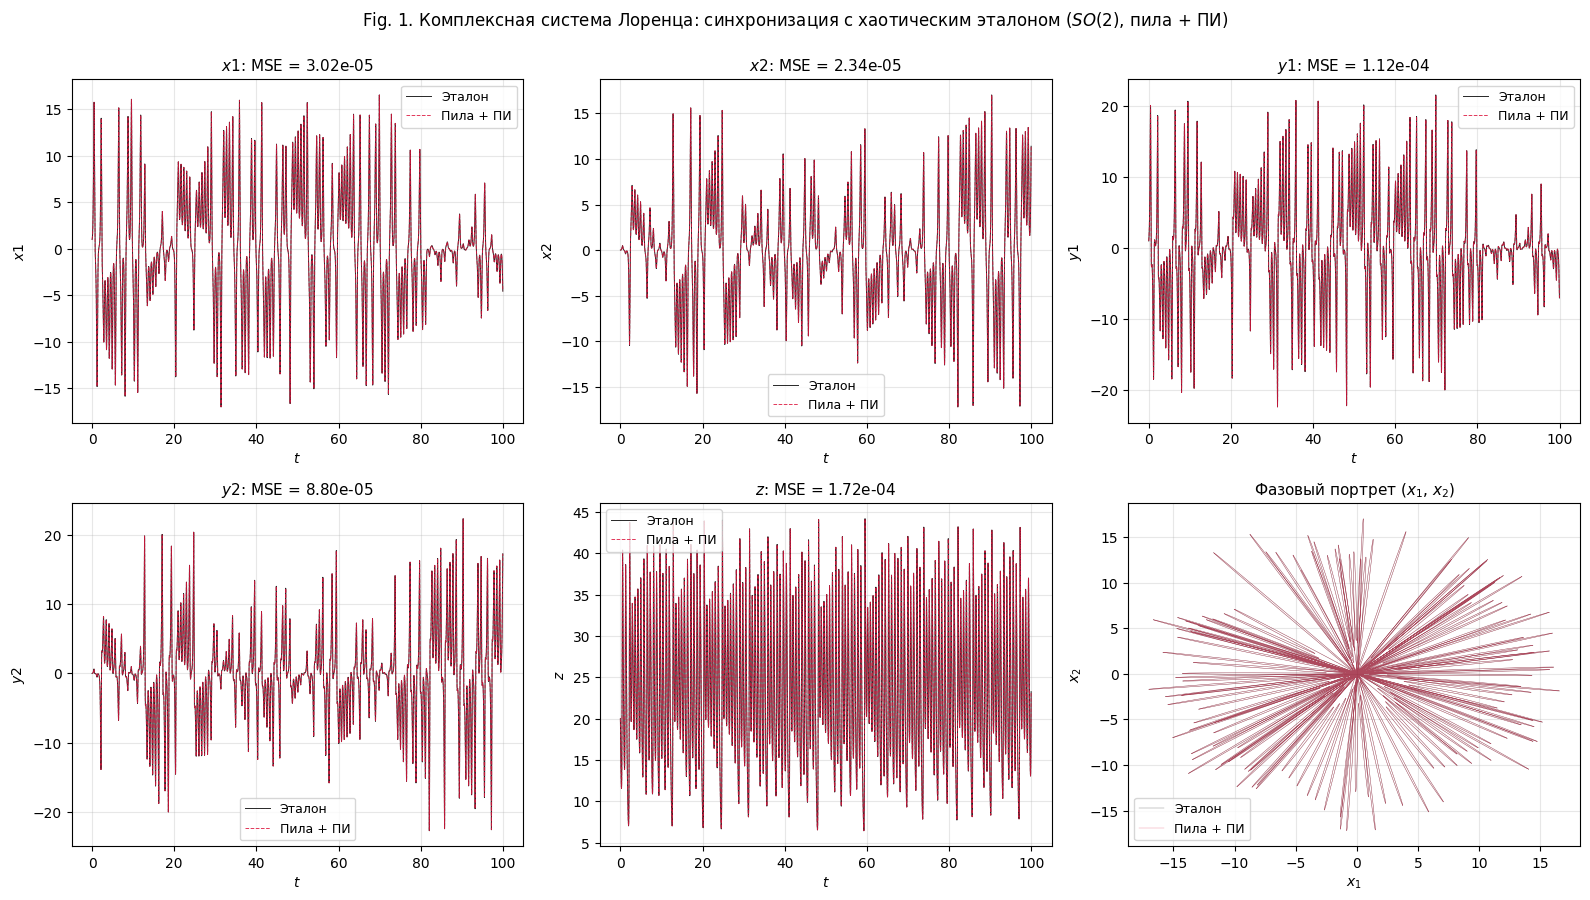

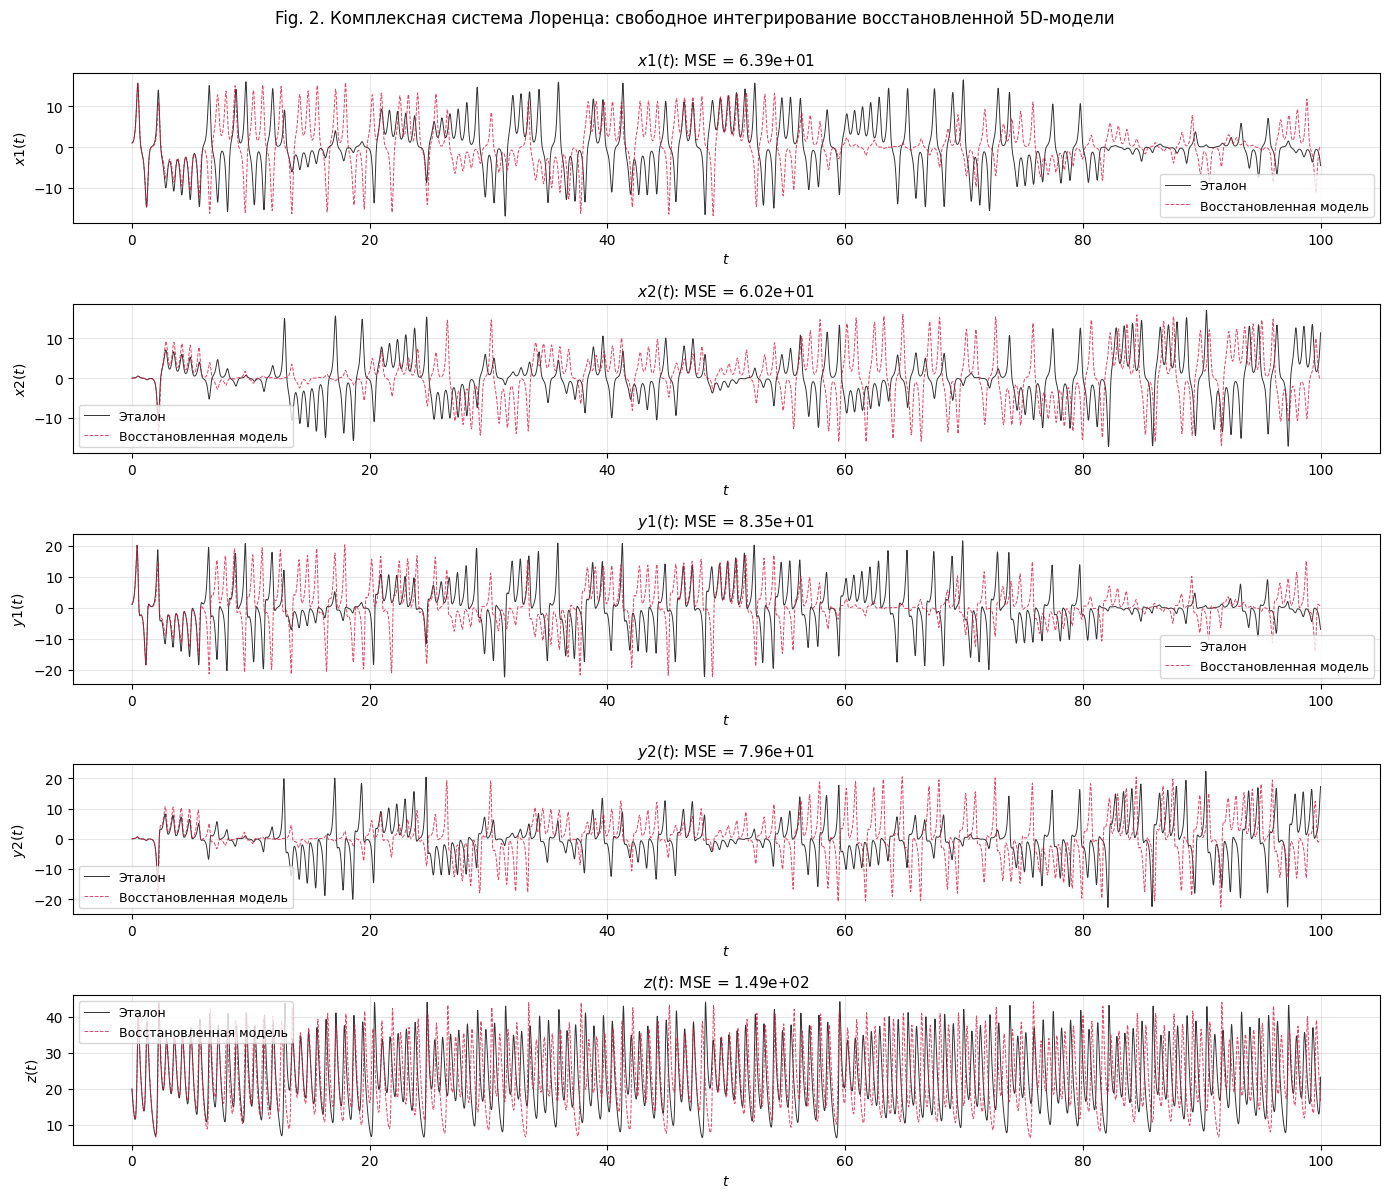


Сохранено:
  fig1_complex_lorenz.png       — синхронизация
  fig2_complex_lorenz_model.png — свободное интегрирование


In [9]:
# ======================================================================
# FIG. 1: комплексный Лоренц — синхронизация (пила + ПИ)
# ======================================================================
from scipy.interpolate import interp1d
from scipy.signal import sawtooth
import matplotlib.pyplot as plt

# --- интерполяторы эталона ---
x1_ref_f = interp1d(t, X[:, 0], fill_value='extrapolate')
x2_ref_f = interp1d(t, X[:, 1], fill_value='extrapolate')
y1_ref_f = interp1d(t, X[:, 2], fill_value='extrapolate')
y2_ref_f = interp1d(t, X[:, 3], fill_value='extrapolate')
z_ref_f  = interp1d(t, X[:, 4], fill_value='extrapolate')

A_saw, f_saw = 0.01, 0.1
Kp, Ki = 20.0, 1.0

def u_saw(t):
    return A_saw * sawtooth(2 * np.pi * f_saw * t)

def closed_loop_rhs(t, state):
    x1, x2, y1, y2, z = state[:5]
    q = state[5:10]
    x1 = np.clip(x1, -50, 50); x2 = np.clip(x2, -50, 50)
    y1 = np.clip(y1, -50, 50); y2 = np.clip(y2, -50, 50)
    z  = np.clip(z, -10, 100)

    # правая часть восстановленной модели
    phi_eq = basis_eq(x1, x2, y1, y2, z)
    phi_inv = basis_inv(x1, x2, y1, y2, z)
    dx = []
    for j, name in enumerate(['x1', 'x2', 'y1', 'y2', 'z']):
        c, c0 = coefs[name]
        phi = phi_eq if j < 4 else phi_inv
        dx.append(np.dot(c, phi) + c0)

    refs = [x1_ref_f(t), x2_ref_f(t), y1_ref_f(t), y2_ref_f(t), z_ref_f(t)]
    current = [x1, x2, y1, y2, z]
    err = np.array([refs[i] - current[i] for i in range(5)])
    u_pi = Kp * err + Ki * q

    u = u_pi.copy()
    u[0] += u_saw(t)               # пила только в x1-канал

    dstate = np.zeros(10)
    for j in range(5):
        dstate[j] = dx[j] + u[j]
    dstate[5:10] = err
    return dstate

state0_ctrl = np.concatenate([X[0], np.zeros(5)])
sol_ctrl = solve_ivp(closed_loop_rhs, (t[0], t[-1]), state0_ctrl,
                     t_eval=t, method='BDF',
                     rtol=1e-5, atol=1e-8, max_step=0.5)
X_ctrl = sol_ctrl.y[:5].T

print("\nMSE слежения (пила + ПИ):")
mse_ctrl = {}
for j, name in enumerate(['x1', 'x2', 'y1', 'y2', 'z']):
    mse_ctrl[name] = np.mean((X[:, j] - X_ctrl[:, j])**2)
    print(f"  {name}: {mse_ctrl[name]:.3e}")

fig1, axes = plt.subplots(2, 3, figsize=(16, 9))

for j, name in enumerate(['x1', 'x2', 'y1']):
    ax = axes[0, j]
    ax.plot(t, X[:, j], lw=0.7, alpha=0.85,
            label='Эталон', color='black')
    ax.plot(t, X_ctrl[:, j], '--', lw=0.7, alpha=0.85,
            label='Пила + ПИ', color='crimson')
    ax.set_xlabel('$t$'); ax.set_ylabel(f'${name}$')
    ax.set_title(f'${name}$: MSE = {mse_ctrl[name]:.2e}', fontsize=11)
    ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

for j, name in enumerate(['y2', 'z']):
    ax = axes[1, j]
    ax.plot(t, X[:, j+3], lw=0.7, alpha=0.85,
            label='Эталон', color='black')
    ax.plot(t, X_ctrl[:, j+3], '--', lw=0.7, alpha=0.85,
            label='Пила + ПИ', color='crimson')
    ax.set_xlabel('$t$'); ax.set_ylabel(f'${name}$')
    ax.set_title(f'${name}$: MSE = {mse_ctrl[name]:.2e}', fontsize=11)
    ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

ax = axes[1, 2]
ax.plot(X[:, 0], X[:, 1], lw=0.3, alpha=0.5, color='black', label='Эталон')
ax.plot(X_ctrl[:, 0], X_ctrl[:, 1], lw=0.3, alpha=0.5,
        color='crimson', label='Пила + ПИ')
ax.set_xlabel('$x_1$'); ax.set_ylabel('$x_2$')
ax.set_title('Фазовый портрет ($x_1$, $x_2$)', fontsize=11)
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

plt.suptitle('Fig. 1. Комплексная система Лоренца: синхронизация '
             'с хаотическим эталоном ($SO(2)$, пила + ПИ)',
             fontsize=12, y=0.995)
plt.tight_layout()
plt.savefig('fig1_complex_lorenz.png', dpi=300, bbox_inches='tight')
plt.show()


# ======================================================================
# FIG. 2: комплексный Лоренц — свободное интегрирование модели
# ======================================================================
sol_model = solve_ivp(lambda tt, s: F_model(s), (t[0], t[-1]), X[0],
                      t_eval=t, method='LSODA',
                      rtol=1e-8, atol=1e-10)
t_m = sol_model.t
X_m = sol_model.y.T
n_m = min(len(t_m), len(t))

fig2, axes = plt.subplots(5, 1, figsize=(14, 12))

for j, name in enumerate(['x1', 'x2', 'y1', 'y2', 'z']):
    ax = axes[j]
    ax.plot(t[:n_m], X[:n_m, j], lw=0.7, alpha=0.8,
            label='Эталон', color='black')
    ax.plot(t_m[:n_m], X_m[:n_m, j], '--', lw=0.7, alpha=0.8,
            label='Восстановленная модель', color='crimson')
    mse = np.mean((X[:n_m, j] - X_m[:n_m, j])**2)
    ax.set_xlabel('$t$'); ax.set_ylabel(f'${name}(t)$')
    ax.set_title(f'${name}(t)$: MSE = {mse:.2e}', fontsize=11)
    ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

plt.suptitle('Fig. 2. Комплексная система Лоренца: свободное '
             'интегрирование восстановленной 5D-модели',
             fontsize=12, y=0.995)
plt.tight_layout()
plt.savefig('fig2_complex_lorenz_model.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nСохранено:")
print("  fig1_complex_lorenz.png       — синхронизация")
print("  fig2_complex_lorenz_model.png — свободное интегрирование")


ROBUSTNESS TO CONTROLLER PARAMETERS

Kp x Ki grid (mean MSE, T = 30):
          Ki= 0.5  Ki= 1.0  Ki= 4.0
Kp=10.0  4.1e-04  3.4e-04  3.5e-04  
Kp=20.0  1.1e-04  1.4e-04  1.3e-04  
Kp=40.0  4.8e-05  4.7e-05  4.7e-05  

  min = 4.650e-05
  max = 4.111e-04
  ratio max/min = 8.84

Amplitude sweep (Kp=20, Ki=1, f=0.1):
  A = 0.005: MSE = 4.667e-05
  A =  0.01: MSE = 4.650e-05
  A =  0.02: MSE = 4.655e-05

Frequency sweep (Kp=20, Ki=1, A=0.01):
  f =  0.05: MSE = 4.685e-05
  f =   0.1: MSE = 4.650e-05
  f =   0.2: MSE = 4.677e-05


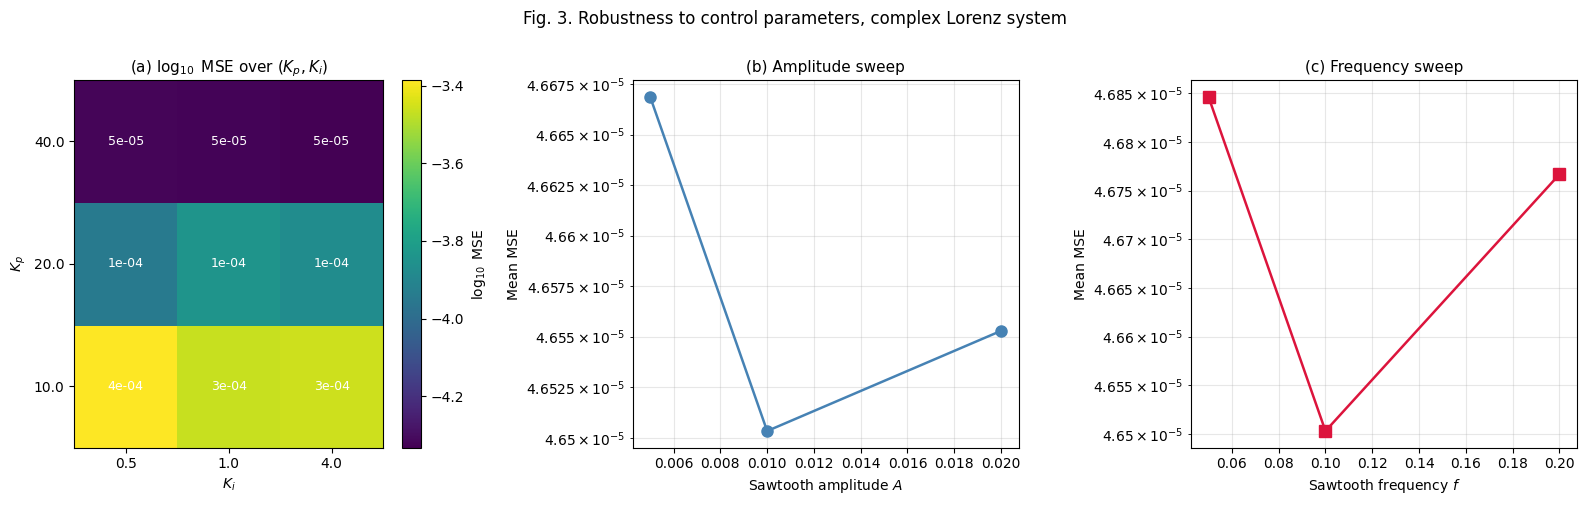


Saved: fig3_lorenz_robustness.png


In [8]:
# ======================================================================
# ROBUSTNESS OF SYNCHRONIZATION TO CONTROLLER PARAMETERS
# ======================================================================
print("\n" + "=" * 72)
print("ROBUSTNESS TO CONTROLLER PARAMETERS")
print("=" * 72)

def run_closed_loop(A_saw_val, f_saw_val, Kp_val, Ki_val,
                    T=30.0, dt=0.01):
    """Fast closed-loop run. Returns mean MSE over the five components."""
    tt = np.arange(0, T, dt)

    def rhs(t, state):
        x1, x2, y1, y2, z = state[:5]
        q = state[5:10]
        x1 = np.clip(x1, -50, 50); x2 = np.clip(x2, -50, 50)
        y1 = np.clip(y1, -50, 50); y2 = np.clip(y2, -50, 50)
        z  = np.clip(z, -10, 100)

        phi_eq = basis_eq(x1, x2, y1, y2, z)
        phi_inv = basis_inv(x1, x2, y1, y2, z)
        dx = []
        for j, name in enumerate(['x1', 'x2', 'y1', 'y2', 'z']):
            c, c0 = coefs[name]
            phi = phi_eq if j < 4 else phi_inv
            dx.append(np.dot(c, phi) + c0)

        refs = [x1_ref_f(t), x2_ref_f(t), y1_ref_f(t),
                y2_ref_f(t), z_ref_f(t)]
        current = [x1, x2, y1, y2, z]
        err = np.array([refs[i] - current[i] for i in range(5)])
        u_pi = Kp_val * err + Ki_val * q
        u = u_pi.copy()
        u[0] += A_saw_val * sawtooth(2 * np.pi * f_saw_val * t)

        dstate = np.zeros(10)
        for j in range(5):
            dstate[j] = dx[j] + u[j]
        dstate[5:10] = err
        return dstate

    state0 = np.concatenate([X[0], np.zeros(5)])
    sol = solve_ivp(rhs, (0, T), state0, t_eval=tt,
                    method='LSODA', rtol=1e-3, atol=1e-6)
    Xc = sol.y[:5].T
    n = min(len(tt), len(X))
    # ignore the first 5 time units (transient)
    i0 = int(5.0 / dt)
    mse = np.mean((X[i0:n, :] - Xc[i0:n, :])**2, axis=0)
    return mse.mean()


# ----------------------------------------------------------------------
# 1) 3x3 grid over (Kp, Ki)
# ----------------------------------------------------------------------
Kp_grid = [10.0, 20.0, 40.0]
Ki_grid = [0.5, 1.0, 4.0]

mse_grid = np.zeros((len(Kp_grid), len(Ki_grid)))

print("\nKp x Ki grid (mean MSE, T = 30):")
print(f"{'':>8}", end='')
for Ki in Ki_grid:
    print(f"  Ki={Ki:>4}", end='')
print()

for i, Kp in enumerate(Kp_grid):
    print(f"Kp={Kp:>4}", end='  ')
    for j, Ki in enumerate(Ki_grid):
        mse_grid[i, j] = run_closed_loop(A_saw, f_saw, Kp, Ki)
        print(f"{mse_grid[i, j]:>7.1e}", end='  ')
    print()

print(f"\n  min = {mse_grid.min():.3e}")
print(f"  max = {mse_grid.max():.3e}")
print(f"  ratio max/min = {mse_grid.max() / mse_grid.min():.2f}")


# ----------------------------------------------------------------------
# 2) Sweep over sawtooth amplitude and frequency
# ----------------------------------------------------------------------
A_sweep = [0.005, 0.01, 0.02]
f_sweep = [0.05, 0.1, 0.2]

mse_A = []
mse_f = []

print("\nAmplitude sweep (Kp=20, Ki=1, f=0.1):")
for A_val in A_sweep:
    m = run_closed_loop(A_val, f_saw, Kp, Ki)
    mse_A.append(m)
    print(f"  A = {A_val:>5}: MSE = {m:.3e}")

print("\nFrequency sweep (Kp=20, Ki=1, A=0.01):")
for f_val in f_sweep:
    m = run_closed_loop(A_saw, f_val, Kp, Ki)
    mse_f.append(m)
    print(f"  f = {f_val:>5}: MSE = {m:.3e}")


# ----------------------------------------------------------------------
# FIG. 3: robustness — heatmap + sweeps
# ----------------------------------------------------------------------
fig3, axes = plt.subplots(1, 3, figsize=(16, 5))

ax = axes[0]
im = ax.imshow(np.log10(mse_grid), cmap='viridis',
               origin='lower', aspect='auto')
ax.set_xticks(range(len(Ki_grid)))
ax.set_xticklabels([f'{v}' for v in Ki_grid])
ax.set_yticks(range(len(Kp_grid)))
ax.set_yticklabels([f'{v}' for v in Kp_grid])
ax.set_xlabel('$K_i$'); ax.set_ylabel('$K_p$')
ax.set_title('(a) $\\log_{10}$ MSE over $(K_p, K_i)$', fontsize=11)
for i in range(len(Kp_grid)):
    for j in range(len(Ki_grid)):
        ax.text(j, i, f'{mse_grid[i,j]:.0e}',
                ha='center', va='center', fontsize=9, color='white')
plt.colorbar(im, ax=ax, label='$\\log_{10}$ MSE')

ax = axes[1]
ax.semilogy(A_sweep, mse_A, 'o-', lw=1.8, ms=8, color='steelblue')
ax.set_xlabel('Sawtooth amplitude $A$')
ax.set_ylabel('Mean MSE')
ax.set_title('(b) Amplitude sweep', fontsize=11)
ax.grid(True, alpha=0.3, which='both')

ax = axes[2]
ax.semilogy(f_sweep, mse_f, 's-', lw=1.8, ms=8, color='crimson')
ax.set_xlabel('Sawtooth frequency $f$')
ax.set_ylabel('Mean MSE')
ax.set_title('(c) Frequency sweep', fontsize=11)
ax.grid(True, alpha=0.3, which='both')

plt.suptitle('Fig. 3. Robustness to control parameters, '
             'complex Lorenz system', fontsize=12, y=1.00)
plt.tight_layout()
plt.savefig('fig3_lorenz_robustness.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nSaved: fig3_lorenz_robustness.png")

SINDy library size: 56 features

Component    |    SINDy MSE |  SINDy terms |      Sym MSE |    Sym terms
------------------------------------------------------------------------------------------
x1           |    6.129e-03 |            2 |    6.129e-03 |            2
x2           |    4.959e-03 |            2 |    4.959e-03 |            2
y1           |    9.675e-03 |            9 |    2.955e-02 |            4
y2           |    1.393e-02 |            9 |    2.952e-02 |            4
z            |    3.568e-02 |            8 |    7.536e-02 |            2

Total active terms: SINDy = 30, Symmetry = 14
Compression factor: 2.14x

NON-ZERO TERMS (SINDy)

dx1/dt:
  -9.977760 * x1
  +9.977769 * y1

dx2/dt:
  -9.977720 * x2
  +9.977791 * y2

dy1/dt:
  +28.742774 * x1
  -1.416582 * y1
  -0.101219 * y2
  -1.035269 * x1*z
  +0.019137 * y1*z
  +0.490470 * x1*x1*y2
  -0.490445 * x1*x2*y1
  -0.319450 * x1*y1*y2
  +0.319428 * x2*y1*y1

dy2/dt:
  +28.706827 * x2
  +0.101627 * y1
  -1.398214 * y2
  -

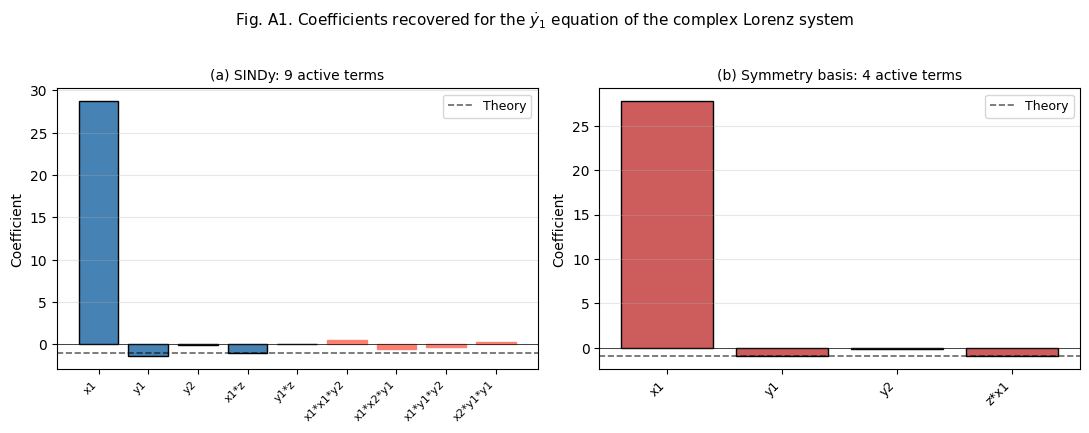


Saved: figA1_sindy_vs_symmetry.png


In [24]:
# ======================================================================
# SINDy (STLSQ) vs symmetry basis - full comparison
# Complex Lorenz system
# Also generates Fig. A1 for Appendix A
# ======================================================================
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

# ----------------------------------------------------------------------
# 0. Data (reference trajectory)
# ----------------------------------------------------------------------
# Assumes X and dX are already loaded:
#   X  : (N, 5) - [x1, x2, y1, y2, z]
#   dX : (N, 5) - derivatives

# ----------------------------------------------------------------------
# 1. Build SINDy library (polynomials of degree <= 3)
# ----------------------------------------------------------------------
def build_polynomial_library(X, degree=3):
    """
    Full polynomial library of degree <= degree.
    Returns: Theta (N, p) and list of feature names.
    """
    N, d = X.shape
    features = []
    names = []

    # Degree 0
    features.append(np.ones(N))
    names.append('1')

    # Degree 1
    for i in range(d):
        features.append(X[:, i])
        names.append(f'v{i}')

    # Degrees 2 and 3 - recursively via combinations with replacement
    from itertools import combinations_with_replacement
    for deg in range(2, degree + 1):
        for combo in combinations_with_replacement(range(d), deg):
            feat = np.ones(N)
            for idx in combo:
                feat = feat * X[:, idx]
            features.append(feat)
            names.append('*'.join(f'v{i}' for i in combo))

    return np.column_stack(features), names


# ----------------------------------------------------------------------
# 1b. Human-readable feature names
# ----------------------------------------------------------------------
VAR_MAP = {'v0': 'x1', 'v1': 'x2', 'v2': 'y1', 'v3': 'y2', 'v4': 'z'}

def humanize(name):
    """Convert v0*v4 -> x1*z etc."""
    if name == '1':
        return '1'
    parts = name.split('*')
    return '*'.join(VAR_MAP.get(p, p) for p in parts)


# ----------------------------------------------------------------------
# 2. STLSQ - Sequential Thresholded Least Squares
# ----------------------------------------------------------------------
def stlsq(Theta, y, threshold=0.01, max_iter=20):
    """
    Classical SINDy solver (Brunton 2016).
    Iteratively:
      1) solve least squares
      2) zero out coefficients below threshold
      3) repeat until convergence
    """
    xi = np.linalg.lstsq(Theta, y, rcond=None)[0]

    for _ in range(max_iter):
        small = np.abs(xi) < threshold
        xi[small] = 0.0

        big = ~small
        if not np.any(big):
            break
        xi_new = np.zeros_like(xi)
        xi_new[big] = np.linalg.lstsq(Theta[:, big], y, rcond=None)[0]

        if np.allclose(xi_new, xi, atol=1e-10):
            xi = xi_new
            break
        xi = xi_new

    return xi


# ----------------------------------------------------------------------
# 3. SINDy identification
# ----------------------------------------------------------------------
def sindy_identify(X, dX, threshold=0.01):
    Theta, names = build_polynomial_library(X, degree=3)
    print(f"SINDy library size: {Theta.shape[1]} features")

    coefs_sindy = []
    for j in range(dX.shape[1]):
        xi = stlsq(Theta, dX[:, j], threshold=threshold)
        coefs_sindy.append(xi)

    return coefs_sindy, Theta, names


# ----------------------------------------------------------------------
# 4. Symmetry basis (as in the paper)
# ----------------------------------------------------------------------
def build_symmetry_library(X):
    x1, x2, y1, y2, z = X[:, 0], X[:, 1], X[:, 2], X[:, 3], X[:, 4]

    # Equivariant functions for x1, x2, y1, y2
    Phi_eq = np.column_stack([
        x1, x2, y1, y2,
        z*x1, z*x2, z*y1, z*y2,
        (x1**2 + x2**2)*x1, (x1**2 + x2**2)*x2,
        (y1**2 + y2**2)*x1, (y1**2 + y2**2)*x2,
        (x1*y1 + x2*y2)*x1, (x1*y1 + x2*y2)*x2,
    ])
    names_eq = ['x1', 'x2', 'y1', 'y2',
                'z*x1', 'z*x2', 'z*y1', 'z*y2',
                '|x|^2*x1', '|x|^2*x2',
                '|y|^2*x1', '|y|^2*x2',
                'Re(xy*)*x1', 'Re(xy*)*x2']

    # Invariant functions for z
    Phi_inv = np.column_stack([
        np.ones_like(x1), z, z**2,
        x1**2 + x2**2,
        y1**2 + y2**2,
        x1*y1 + x2*y2,
    ])
    names_inv = ['1', 'z', 'z^2', '|x|^2', '|y|^2', 'Re(xy*)']

    return Phi_eq, Phi_inv, names_eq, names_inv


def symmetry_identify(X, dX, threshold=0.01):
    Phi_eq, Phi_inv, names_eq, names_inv = build_symmetry_library(X)
    coefs_sym = []
    for j in range(dX.shape[1]):
        Phi = Phi_eq if j < 4 else Phi_inv
        xi = stlsq(Phi, dX[:, j], threshold=threshold)
        coefs_sym.append(xi)
    return coefs_sym, Phi_eq, Phi_inv, names_eq, names_inv


# ----------------------------------------------------------------------
# 5. Metrics and comparison table
# ----------------------------------------------------------------------
def compare(dX, coefs_sindy, coefs_sym, Theta, Phi_eq, Phi_inv):
    print("\n" + "=" * 90)
    print(f"{'Component':<12} | {'SINDy MSE':>12} | {'SINDy terms':>12} | "
          f"{'Sym MSE':>12} | {'Sym terms':>12}")
    print("-" * 90)

    for j, name in enumerate(['x1', 'x2', 'y1', 'y2', 'z']):
        pred_s = Theta @ coefs_sindy[j]
        mse_s = np.mean((dX[:, j] - pred_s)**2)
        n_s = int(np.sum(np.abs(coefs_sindy[j]) > 1e-8))

        Phi = Phi_eq if j < 4 else Phi_inv
        pred_y = Phi @ coefs_sym[j]
        mse_y = np.mean((dX[:, j] - pred_y)**2)
        n_y = int(np.sum(np.abs(coefs_sym[j]) > 1e-8))

        print(f"{name:<12} | {mse_s:>12.3e} | {n_s:>12d} | "
              f"{mse_y:>12.3e} | {n_y:>12d}")

    print("=" * 90)

    total_s = sum(int(np.sum(np.abs(c) > 1e-8)) for c in coefs_sindy)
    total_y = sum(int(np.sum(np.abs(c) > 1e-8)) for c in coefs_sym)
    print(f"\nTotal active terms: SINDy = {total_s}, Symmetry = {total_y}")
    print(f"Compression factor: {total_s / total_y:.2f}x")


# ----------------------------------------------------------------------
# 6. Print non-zero terms in human-readable form
# ----------------------------------------------------------------------
def print_terms(coefs, names, label):
    print("\n" + "=" * 70)
    print(f"NON-ZERO TERMS ({label})")
    print("=" * 70)
    for j, comp in enumerate(['x1', 'x2', 'y1', 'y2', 'z']):
        print(f"\nd{comp}/dt:")
        for name, coef in zip(names, coefs[j]):
            if abs(coef) > 1e-8:
                print(f"  {coef:+.6f} * {humanize(name)}")


# ----------------------------------------------------------------------
# 7. Main run
# ----------------------------------------------------------------------
coefs_sindy, Theta, names = sindy_identify(X, dX, threshold=0.01)
coefs_sym, Phi_eq, Phi_inv, names_eq, names_inv = symmetry_identify(
    X, dX, threshold=0.01)

compare(dX, coefs_sindy, coefs_sym, Theta, Phi_eq, Phi_inv)

print_terms(coefs_sindy, names, 'SINDy')

# also print symmetry-basis terms, for direct comparison in the paper
print("\n" + "=" * 70)
print("NON-ZERO TERMS (symmetry basis)")
print("=" * 70)
for j, comp in enumerate(['x1', 'x2', 'y1', 'y2', 'z']):
    print(f"\nd{comp}/dt:")
    names_used = names_eq if j < 4 else names_inv
    for name, coef in zip(names_used, coefs_sym[j]):
        if abs(coef) > 1e-8:
            print(f"  {coef:+.6f} * {name}")


# ----------------------------------------------------------------------
# 8. Fig. A1: coefficient comparison for the y1 equation
# ----------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))

# --- left: SINDy coefficients for y1 ---
ax = axes[0]
ax.axhline(0, color='black', lw=0.5)
ax.axhline(-1, color='black', ls='--', lw=1.2, alpha=0.6,
           label='Theory')

active_s = np.where(np.abs(coefs_sindy[2]) > 1e-8)[0]
labels_s = [humanize(names[k]) for k in active_s]
vals_s = coefs_sindy[2][active_s]

colors_s = ['steelblue' if abs(v - round(v)) < 1e-6 else 'salmon'
            for v in vals_s]
ax.bar(range(len(active_s)), vals_s,
       color='steelblue', edgecolor='black')
# highlight the spurious cubic pairs
for i, v in enumerate(vals_s):
    if abs(v) > 1e-6 and abs(v) < 1.0 and abs(abs(v) - 0.4) < 0.15:
        ax.patches[i].set_color('salmon')

ax.set_xticks(range(len(active_s)))
ax.set_xticklabels(labels_s, rotation=45, fontsize=8, ha='right')
ax.set_ylabel('Coefficient')
ax.set_title('(a) SINDy: 9 active terms', fontsize=10)
ax.legend(fontsize=9); ax.grid(True, alpha=0.3, axis='y')

# --- right: symmetry-basis coefficients for y1 ---
ax = axes[1]
ax.axhline(0, color='black', lw=0.5)
ax.axhline(-1, color='black', ls='--', lw=1.2, alpha=0.6,
           label='Theory')

active_y = np.where(np.abs(coefs_sym[2]) > 1e-8)[0]
labels_y = [names_eq[k] for k in active_y]
vals_y = coefs_sym[2][active_y]

ax.bar(range(len(active_y)), vals_y,
       color='indianred', edgecolor='black')
ax.set_xticks(range(len(active_y)))
ax.set_xticklabels(labels_y, rotation=45, fontsize=9, ha='right')
ax.set_ylabel('Coefficient')
ax.set_title('(b) Symmetry basis: 4 active terms', fontsize=10)
ax.legend(fontsize=9); ax.grid(True, alpha=0.3, axis='y')

plt.suptitle('Fig. A1. Coefficients recovered for the $\\dot{y}_1$ '
             'equation of the complex Lorenz system',
             fontsize=11, y=1.02)
plt.tight_layout()
plt.savefig('figA1_sindy_vs_symmetry.png',
            dpi=300, bbox_inches='tight')
plt.show()

print("\nSaved: figA1_sindy_vs_symmetry.png")